In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import random
import sc_toolbox
import pertpy 

import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

pd.set_option('display.max_columns', None)

%load_ext rpy2.ipython

In [2]:
%%R
library(GSA)
library(msigdbr)
library(fgsea)
library(data.table)
library(tidyverse) # includes ggplot2, for data visualisation. dplyr, for data manipulation.
library(RColorBrewer) # for a colourful plot

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second()
✖ purrr::transpose()   masks data.table::transpose()
✖ lubridate::wday() 

data.table 1.16.4 using 1 threads (see ?getDTthreads).  Latest news: r-datatable.com


In [3]:
%%R

set.seed(42)

# Figure out how to set up gene lists

In [4]:
%%R

all_gene_sets = msigdbr(species = "Mus musculus")
head(all_gene_sets)

# A tibble: 6 × 18
  gs_cat gs_subcat      gs_name        gene_symbol entrez_gene ensembl_gene     
  <chr>  <chr>          <chr>          <chr>             <int> <chr>            
1 C3     MIR:MIR_Legacy AAACCAC_MIR140 Abcc4            239273 ENSMUSG000000328…
2 C3     MIR:MIR_Legacy AAACCAC_MIR140 Abraxas2         109359 ENSMUSG000000309…
3 C3     MIR:MIR_Legacy AAACCAC_MIR140 Actn4             60595 ENSMUSG000000548…
4 C3     MIR:MIR_Legacy AAACCAC_MIR140 Acvr1             11477 ENSMUSG000000268…
5 C3     MIR:MIR_Legacy AAACCAC_MIR140 Adam9             11502 ENSMUSG000000315…
6 C3     MIR:MIR_Legacy AAACCAC_MIR140 Adamts5           23794 ENSMUSG000000228…
# ℹ 12 more variables: human_gene_symbol <chr>, human_entrez_gene <int>,
#   human_ensembl_gene <chr>, gs_id <chr>, gs_pmid <chr>, gs_geoid <chr>,
#   gs_exact_source <chr>, gs_url <chr>, gs_description <chr>, taxon_id <int>,
#   ortholog_sources <chr>, num_ortholog_sources <dbl>


In [5]:
%%R

# Get the MSigDB collections
collections <- msigdbr_collections()

# Print all rows of the tibble
print(collections, n = Inf)

# A tibble: 23 × 3
   gs_cat gs_subcat         num_genesets
   <chr>  <chr>                    <int>
 1 C1     ""                         299
 2 C2     "CGP"                     3384
 3 C2     "CP"                        29
 4 C2     "CP:BIOCARTA"              292
 5 C2     "CP:KEGG"                  186
 6 C2     "CP:PID"                   196
 7 C2     "CP:REACTOME"             1615
 8 C2     "CP:WIKIPATHWAYS"          664
 9 C3     "MIR:MIRDB"               2377
10 C3     "MIR:MIR_Legacy"           221
11 C3     "TFT:GTRD"                 518
12 C3     "TFT:TFT_Legacy"           610
13 C4     "CGN"                      427
14 C4     "CM"                       431
15 C5     "GO:BP"                   7658
16 C5     "GO:CC"                   1006
17 C5     "GO:MF"                   1738
18 C5     "HPO"                     5071
19 C6     ""                         189
20 C7     "IMMUNESIGDB"             4872
21 C7     "VAX"                      347
22 C8     ""                         7

In [6]:
%%R

#Retrieve human H (hallmark gene sets) 
msigdbr_df <- msigdbr(species = "mouse", category = "H")


head(msigdbr_df)

# A tibble: 6 × 18
  gs_cat gs_subcat gs_name               gene_symbol entrez_gene ensembl_gene   
  <chr>  <chr>     <chr>                 <chr>             <int> <chr>          
1 H      ""        HALLMARK_ADIPOGENESIS Abca1             11303 ENSMUSG0000001…
2 H      ""        HALLMARK_ADIPOGENESIS Abcb8             74610 ENSMUSG0000002…
3 H      ""        HALLMARK_ADIPOGENESIS Acaa2             52538 ENSMUSG0000003…
4 H      ""        HALLMARK_ADIPOGENESIS Acadl             11363 ENSMUSG0000002…
5 H      ""        HALLMARK_ADIPOGENESIS Acadm             11364 ENSMUSG0000006…
6 H      ""        HALLMARK_ADIPOGENESIS Acads             11409 ENSMUSG0000002…
# ℹ 12 more variables: human_gene_symbol <chr>, human_entrez_gene <int>,
#   human_ensembl_gene <chr>, gs_id <chr>, gs_pmid <chr>, gs_geoid <chr>,
#   gs_exact_source <chr>, gs_url <chr>, gs_description <chr>, taxon_id <int>,
#   ortholog_sources <chr>, num_ortholog_sources <dbl>


In [7]:
%%R

pathwaysH = split(x = msigdbr_df$gene_symbol, f = msigdbr_df$gs_name)
head(pathwaysH)

$HALLMARK_ADIPOGENESIS
  [1] "Abca1"    "Abcb8"    "Acaa2"    "Acadl"    "Acadm"    "Acads"   
  [7] "Acly"     "Aco2"     "Acox1"    "Adcy6"    "Adig"     "Adipoq"  
 [13] "Adipor2"  "Agpat3"   "Aifm1"    "Ak2"      "Aldh2"    "Aldoa"   
 [19] "Angpt1"   "Angptl4"  "Aplp2"    "Apoe"     "Araf"     "Arl4a"   
 [25] "Atl2"     "Atp1b3"   "Atp5o"    "Baz2a"    "Bckdha"   "Bcl2l13" 
 [31] "Bcl6"     "C3"       "Cat"      "Cavin1"   "Cavin2"   "Ccng2"   
 [37] "Cd151"    "Cd302"    "Cd36"     "Cdkn2c"   "Chchd10"  "Chuk"    
 [43] "Cidea"    "Cmbl"     "Cmpk1"    "Col15a1"  "Col4a1"   "Coq3"    
 [49] "Coq5"     "Coq9"     "Cox6a1"   "Cox7b"    "Cox8a"    "Cpt2"    
 [55] "Crat"     "Cs"       "Cyc1"     "Cyp4b1"   "Dbt"      "Ddt"     
 [61] "Decr1"    "Dgat1"    "Dhcr7"    "Dhrs7"    "Dhrs7b"   "Dlat"    
 [67] "Dld"      "Dnajb9"   "Dnajc15"  "Dram2"    "Ech1"     "Echs1"   
 [73] "Elmod3"   "Elovl6"   "Enpp2"    "Ephx2"    "Esrra"    "Esyt1"   
 [79] "Etfb"     "Fabp4"    "Fah"      "F

In [8]:
%%R

options(ports=8888)

# LPC_demyel OPC

In [9]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/LPC_OPC_early_voom_wqw_UPDATED.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

       gene     logFC  AveExpr         t      P.Value    adj.P.Val        B
1       C4b  4.969368 5.166741  17.92496 1.262250e-11 1.019015e-07 15.94549
2 Serpina3n  5.016019 5.574485  16.22826 5.319566e-11 1.760439e-07 15.14196
3    Dbndd2  4.443583 4.783055  15.99661 6.541952e-11 1.760439e-07 14.73933
4   Col16a1  2.322603 5.886618  15.56691 9.670652e-11 1.951779e-07 14.77328
5    Unc13c -2.726557 6.612704 -13.55744 6.896989e-10 9.751585e-07 12.69665
6     Josd2  3.069189 4.524543  13.50979 7.247555e-10 9.751585e-07 12.74182


In [10]:
%%R

dim(df)

[1] 8073    7


In [11]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "C4b"       "Serpina3n" "Dbndd2"    "Col16a1"   "Unc13c"    "Josd2"    


In [12]:
%%R
# Check column names in the dataframe
colnames(df)

[1] "gene"      "logFC"     "AveExpr"   "t"         "P.Value"   "adj.P.Val"
[7] "B"        


In [13]:
%%R

# Compute ranking score using all genes
df$ranking_score <- -log10(df$P.Value) * sign(df$logFC)

# Assign gene names
rankings <- df$ranking_score
names(rankings) <- df$gene

# Sort rankings
rankings <- sort(rankings, decreasing = TRUE)

In [14]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


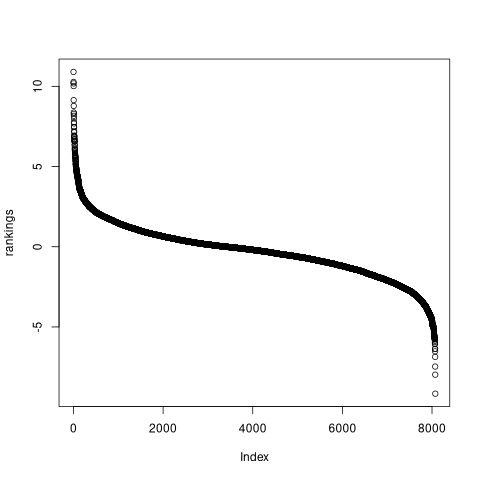

In [15]:
%%R

plot(rankings)

In [16]:
%%R

max(rankings)

[1] 10.89885


In [17]:
%%R

min(rankings)

[1] -9.16134


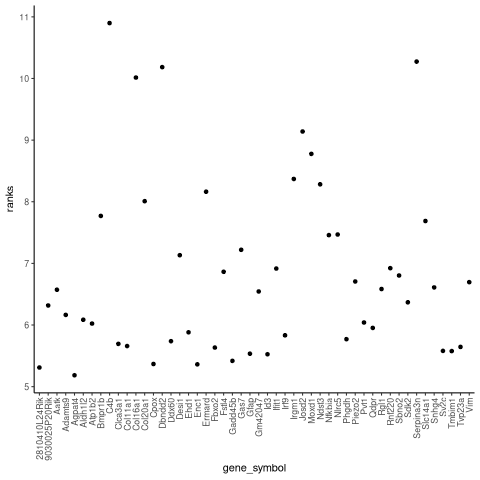

In [18]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Figure out how to set up gene lists

In [19]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [20]:
%%R
fgsea_res

                                       pathway         pval         padj
                                        <char>        <num>        <num>
 1:                      HALLMARK_ADIPOGENESIS 1.103387e-02 2.469484e-02
 2:               HALLMARK_ALLOGRAFT_REJECTION 7.526984e-03 2.211052e-02
 3:                 HALLMARK_ANDROGEN_RESPONSE 6.950067e-01 8.440982e-01
 4:                   HALLMARK_APICAL_JUNCTION 5.142857e-01 6.906122e-01
 5:                         HALLMARK_APOPTOSIS 8.718442e-03 2.276482e-02
 6:              HALLMARK_BILE_ACID_METABOLISM 4.648194e-05 2.730814e-04
 7:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 6.818182e-02 1.281818e-01
 8:                       HALLMARK_COAGULATION 3.935484e-01 5.450980e-01
 9:                        HALLMARK_COMPLEMENT 8.560000e-01 8.940444e-01
10:                        HALLMARK_DNA_REPAIR 8.437469e-05 4.406234e-04
11:                       HALLMARK_E2F_TARGETS 3.132812e-06 2.454036e-05
12: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 2.18

In [21]:
%%R

dim(fgsea_res)

[1] 47  8


In [22]:
%%R

fwrite(fgsea_res, file = "./files/fgsea_LPC_demyel_OPC_allgenes.csv")

In [23]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL2_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL2_significant)

[1] 23  8


In [24]:
%%R

head(fgsea_MOL2_significant)

                         pathway         pval         padj   log2err         ES
                          <char>        <num>        <num>     <num>      <num>
1:         HALLMARK_ADIPOGENESIS 1.103387e-02 2.469484e-02 0.3807304  0.3097458
2:  HALLMARK_ALLOGRAFT_REJECTION 7.526984e-03 2.211052e-02 0.4070179  0.4294806
3:            HALLMARK_APOPTOSIS 8.718442e-03 2.276482e-02 0.3807304  0.3721996
4: HALLMARK_BILE_ACID_METABOLISM 4.648194e-05 2.730814e-04 0.5573322 -0.6168784
5:           HALLMARK_DNA_REPAIR 8.437469e-05 4.406234e-04 0.5384341  0.4189501
6:          HALLMARK_E2F_TARGETS 3.132812e-06 2.454036e-05 0.6272567  0.4606853
         NES  size                               leadingEdge
       <num> <int>                                    <list>
1:  1.378597   132   Qdpr,Taldo1,Samm50,Pim3,Ak2,Dnajc15,...
2:  1.641442    57     Tgfb2,Apbb1,Nme1,Csf1,Stat1,Eif5a,...
3:  1.495822    73  Gadd45b,Tgfb2,Cdkn1a,Casp3,Lmna,Ier3,...
4: -1.945029    41 Abca6,Nr3c2,Hsd17b11,Optn,Idi1,Cyp7b

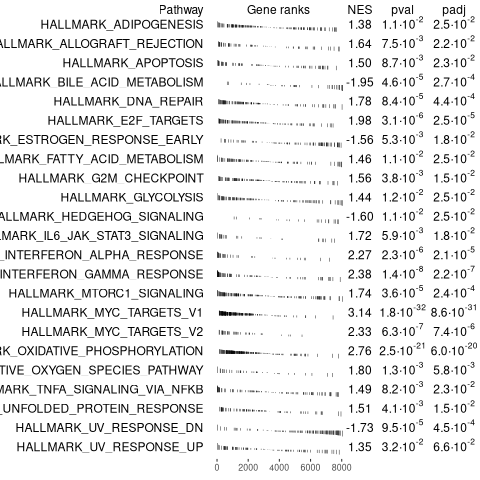

In [25]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL2_significant$pathway], 
              rankings, 
              fgsea_MOL2_significant, 
              gseaParam = 0.5)

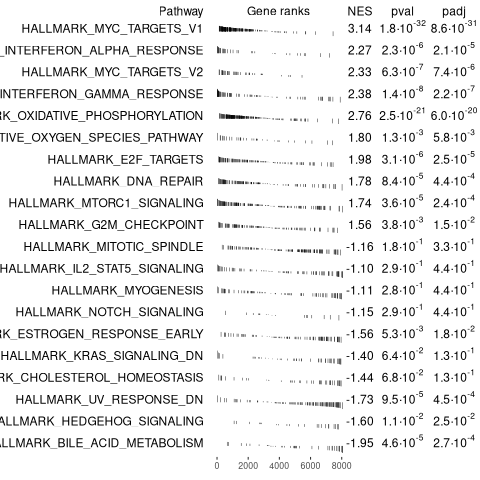

In [26]:
%%R

topUp <- fgsea_res %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)
topDown <- fgsea_res %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)
topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)
plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_res, 
              gseaParam = 0.5)

In [27]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL2_significant[order(pval)][padj < 0.05], 
                                      pathwaysH, rankings)

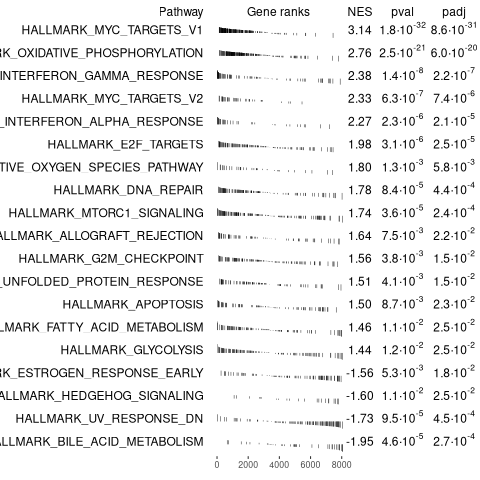

In [28]:
%%R

mainPathways <- fgsea_MOL2_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL2_significant, 
              gseaParam = 0.5)

In [29]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

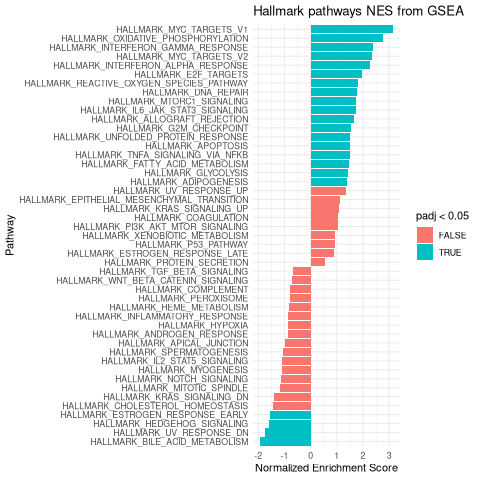

In [30]:
%%R

ggplot(fgseaResTidy, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill=padj<0.05)) +
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",
       title="Hallmark pathways NES from GSEA") + 
  theme_minimal()


#https://stephenturner.github.io/deseq-to-fgsea/#using_the_fgsea_package

In [31]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                padj   NES  size
  <chr>                                 <dbl> <dbl> <int>
1 HALLMARK_MYC_TARGETS_V1            8.63e-31  3.14   180
2 HALLMARK_OXIDATIVE_PHOSPHORYLATION 5.98e-20  2.76   181
3 HALLMARK_INTERFERON_GAMMA_RESPONSE 2.22e- 7  2.38    69
4 HALLMARK_MYC_TARGETS_V2            7.41e- 6  2.33    35
5 HALLMARK_INTERFERON_ALPHA_RESPONSE 2.13e- 5  2.27    32
6 HALLMARK_E2F_TARGETS               2.45e- 5  1.98   106


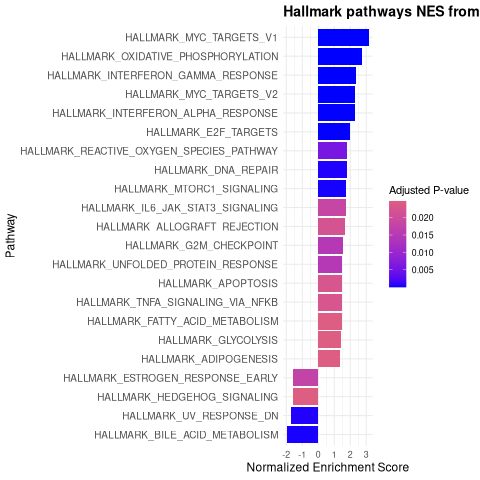

In [32]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

In [33]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                padj   NES  size
  <chr>                                 <dbl> <dbl> <int>
1 HALLMARK_MYC_TARGETS_V1            8.63e-31  3.14   180
2 HALLMARK_OXIDATIVE_PHOSPHORYLATION 5.98e-20  2.76   181
3 HALLMARK_INTERFERON_GAMMA_RESPONSE 2.22e- 7  2.38    69
4 HALLMARK_MYC_TARGETS_V2            7.41e- 6  2.33    35
5 HALLMARK_INTERFERON_ALPHA_RESPONSE 2.13e- 5  2.27    32
6 HALLMARK_E2F_TARGETS               2.45e- 5  1.98   106


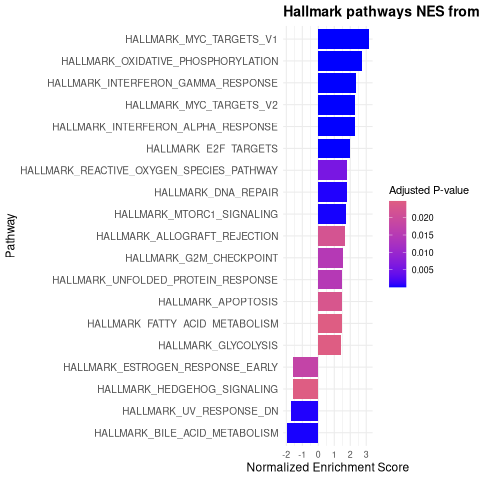

In [34]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )


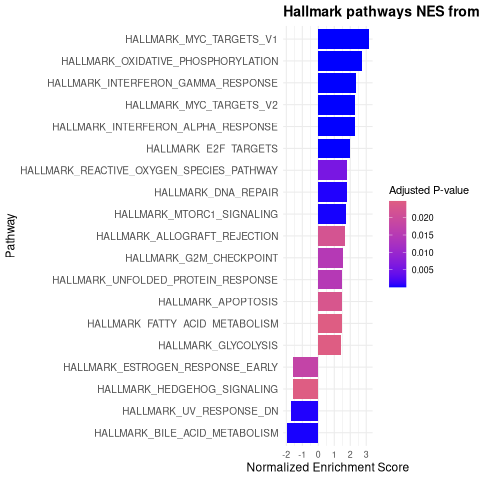

In [35]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/LPC_demyel_MOL_F_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [36]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                       padj   NES  size
  <chr>                        <dbl> <dbl> <int>
1 MYC_TARGETS_V1            8.63e-31  3.14   180
2 OXIDATIVE_PHOSPHORYLATION 5.98e-20  2.76   181
3 INTERFERON_GAMMA_RESPONSE 2.22e- 7  2.38    69
4 MYC_TARGETS_V2            7.41e- 6  2.33    35
5 INTERFERON_ALPHA_RESPONSE 2.13e- 5  2.27    32
6 E2F_TARGETS               2.45e- 5  1.98   106


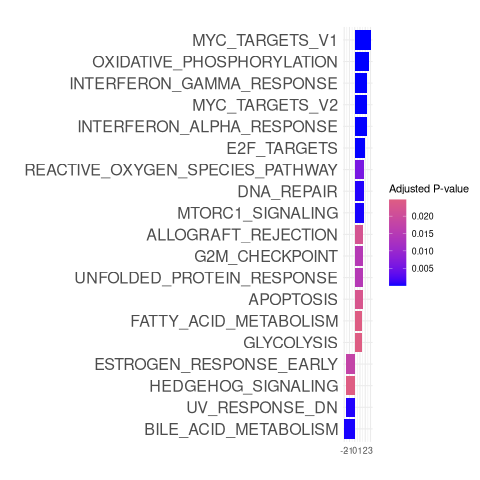

In [37]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 16),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 16, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/LPC_demyel_MOL_hallmark_pathways_NES_GSEA_trimmed.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

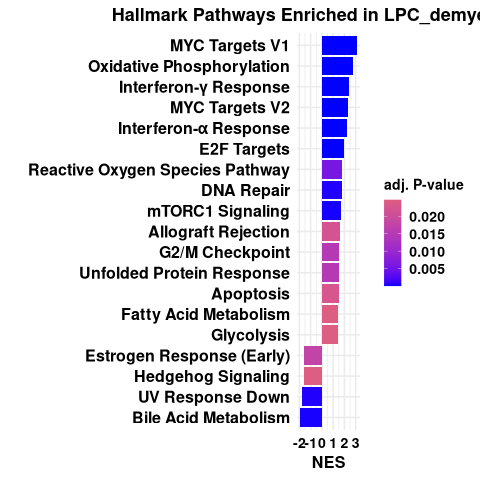

In [42]:
%%R

# Define your selected pathways and their pretty names
# Define selected pathways and their pretty names
pathway_name_format <- c(
  "ADIPOGENESIS"                    = "Adipogenesis",
  "ALLOGRAFT_REJECTION"             = "Allograft Rejection",
  "APOPTOSIS"                       = "Apoptosis",
  "BILE_ACID_METABOLISM"            = "Bile Acid Metabolism",
  "DNA_REPAIR"                       = "DNA Repair",
  "E2F_TARGETS"                      = "E2F Targets",
  "ESTROGEN_RESPONSE_EARLY"          = "Estrogen Response (Early)",
  "FATTY_ACID_METABOLISM"            = "Fatty Acid Metabolism",
  "G2M_CHECKPOINT"                   = "G2/M Checkpoint",
  "GLYCOLYSIS"                        = "Glycolysis",
  "HEDGEHOG_SIGNALING"                = "Hedgehog Signaling",
  "IL6_JAK_STAT3_SIGNALING"           = "IL-6/JAK/STAT3 Signaling",
  "INTERFERON_ALPHA_RESPONSE"         = "Interferon-α Response",
  "INTERFERON_GAMMA_RESPONSE"         = "Interferon-γ Response",
  "MTORC1_SIGNALING"                  = "mTORC1 Signaling",
  "MYC_TARGETS_V1"                    = "MYC Targets V1",
  "MYC_TARGETS_V2"                    = "MYC Targets V2",
  "OXIDATIVE_PHOSPHORYLATION"         = "Oxidative Phosphorylation",
  "REACTIVE_OXYGEN_SPECIES_PATHWAY"   = "Reactive Oxygen Species Pathway",
  "TNFA_SIGNALING_VIA_NFKB"           = "TNFα Signaling via NF-κB",
  "UNFOLDED_PROTEIN_RESPONSE"         = "Unfolded Protein Response",
  "UV_RESPONSE_DN"                     = "UV Response Down",
  "UV_RESPONSE_UP"                     = "UV Response Up"
)
# Filter only the selected pathways and apply pretty names
filtered_fgseaResSignificant <- filtered_fgseaResSignificant %>%
  filter(pathway %in% names(pathway_name_format)) %>%
  mutate(pretty_pathway = pathway_name_format[pathway])

# Create the improved ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pretty_pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(
    low = "#0000FF",
    high = "#de5d83",
    na.value = "black",
    name = "adj. P-value"
  ) +
  labs(
    x = "",
    y = "NES",
    title = "Hallmark Pathways Enriched in LPC_demyel OPCs"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    axis.text.y = element_text(size = 16, face = "bold", color = "black"),
    axis.text.x = element_text(size = 14, face = "bold", color = "black"),
    axis.title = element_text(size = 16, face = "bold", color = "black"),
    plot.title = element_text(size = 18, face = "bold", color = "black", hjust = 0.5),
    legend.title = element_text(size = 14, face = "bold", color = "black"),
    legend.text = element_text(size = 14, face = "bold", color = "black")
  )

# Save high-resolution PNG
ggsave("./figures/GSEA/OPC_selected_hallmark_pathways_NES_GSEA.png",
       plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [38]:
%%R

filtered_fgseaResSignificant_LPC_demyel <- fgsea_MOL2_significant
# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant_LPC_demyel$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant_LPC_demyel$pathway)
head(filtered_fgseaResSignificant_LPC_demyel)

                pathway         pval         padj   log2err         ES
                 <char>        <num>        <num>     <num>      <num>
1:         ADIPOGENESIS 1.103387e-02 2.469484e-02 0.3807304  0.3097458
2:  ALLOGRAFT_REJECTION 7.526984e-03 2.211052e-02 0.4070179  0.4294806
3:            APOPTOSIS 8.718442e-03 2.276482e-02 0.3807304  0.3721996
4: BILE_ACID_METABOLISM 4.648194e-05 2.730814e-04 0.5573322 -0.6168784
5:           DNA_REPAIR 8.437469e-05 4.406234e-04 0.5384341  0.4189501
6:          E2F_TARGETS 3.132812e-06 2.454036e-05 0.6272567  0.4606853
         NES  size                               leadingEdge
       <num> <int>                                    <list>
1:  1.378597   132   Qdpr,Taldo1,Samm50,Pim3,Ak2,Dnajc15,...
2:  1.641442    57     Tgfb2,Apbb1,Nme1,Csf1,Stat1,Eif5a,...
3:  1.495822    73  Gadd45b,Tgfb2,Cdkn1a,Casp3,Lmna,Ier3,...
4: -1.945029    41 Abca6,Nr3c2,Hsd17b11,Optn,Idi1,Cyp7b1,...
5:  1.782804   105        Taf10,Ak3,Nme1,Trp53,Guk1,Rpa2,...
6:  1

In [39]:
%%R
unique(filtered_fgseaResSignificant_LPC_demyel$pathway)

 [1] "ADIPOGENESIS"                    "ALLOGRAFT_REJECTION"            
 [3] "APOPTOSIS"                       "BILE_ACID_METABOLISM"           
 [5] "DNA_REPAIR"                      "E2F_TARGETS"                    
 [7] "ESTROGEN_RESPONSE_EARLY"         "FATTY_ACID_METABOLISM"          
 [9] "G2M_CHECKPOINT"                  "GLYCOLYSIS"                     
[11] "HEDGEHOG_SIGNALING"              "IL6_JAK_STAT3_SIGNALING"        
[13] "INTERFERON_ALPHA_RESPONSE"       "INTERFERON_GAMMA_RESPONSE"      
[15] "MTORC1_SIGNALING"                "MYC_TARGETS_V1"                 
[17] "MYC_TARGETS_V2"                  "OXIDATIVE_PHOSPHORYLATION"      
[19] "REACTIVE_OXYGEN_SPECIES_PATHWAY" "TNFA_SIGNALING_VIA_NFKB"        
[21] "UNFOLDED_PROTEIN_RESPONSE"       "UV_RESPONSE_DN"                 
[23] "UV_RESPONSE_UP"                 


In [40]:
%%R
library(data.table)
fwrite(filtered_fgseaResSignificant_LPC_demyel, file = "./files/filtered_fgseaResSignificant_LPC_demyel_OPCs_allgenes.csv")

# LPC_demyel_MOL

In [9]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/LPC_demyel_MOL_all_voom_wqw_UPDATED.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

       gene    logFC  AveExpr        t      P.Value    adj.P.Val        B
1 Serpina3n 6.846376 6.343200 25.45141 2.798568e-12 2.293260e-08 18.66274
2     Masp1 3.692606 5.577334 24.74119 3.982737e-12 2.293260e-08 18.30314
3       C4b 4.153437 6.984800 23.12509 9.231433e-12 3.138267e-08 17.51491
4   Col16a1 2.868299 4.100386 22.81779 1.090055e-11 3.138267e-08 17.21186
5     Pros1 3.613816 4.020028 21.36942 2.458354e-11 5.662080e-08 16.49580
6    Cachd1 2.410952 4.439316 20.77188 3.491687e-11 6.701712e-08 16.17093


In [10]:
%%R

dim(df)

[1] 11516     7


In [11]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "Serpina3n" "Masp1"     "C4b"       "Col16a1"   "Pros1"     "Cachd1"   


In [12]:
%%R
# Check column names in the dataframe
colnames(df)

[1] "gene"      "logFC"     "AveExpr"   "t"         "P.Value"   "adj.P.Val"
[7] "B"        


In [14]:
%%R

# Compute ranking score using all genes
df$ranking_score <- -log10(df$P.Value) * sign(df$logFC)

# Assign gene names
rankings <- df$ranking_score
names(rankings) <- df$gene

# Sort rankings
rankings <- sort(rankings, decreasing = TRUE)

In [15]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


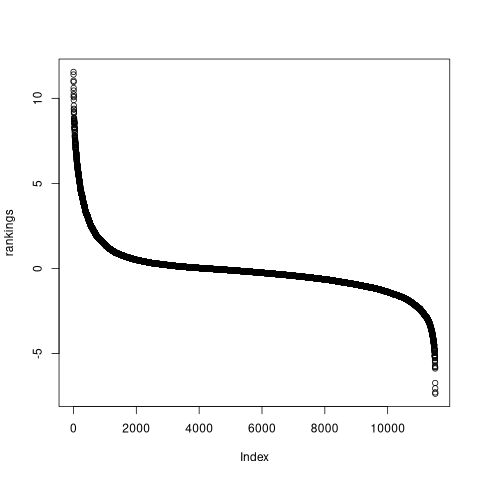

In [16]:
%%R

plot(rankings)

In [17]:
%%R

max(rankings)

[1] 11.55306


In [18]:
%%R

min(rankings)

[1] -7.364204


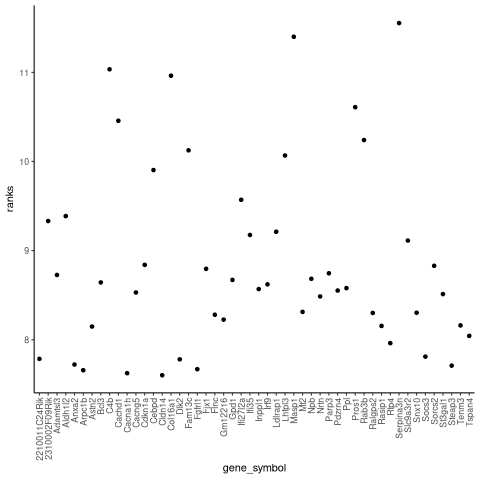

In [19]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Figure out how to set up gene lists

In [20]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [21]:
%%R
fgsea_res

                                       pathway         pval         padj
                                        <char>        <num>        <num>
 1:                      HALLMARK_ADIPOGENESIS 4.796954e-01 5.615947e-01
 2:               HALLMARK_ALLOGRAFT_REJECTION 1.954887e-01 3.189807e-01
 3:                 HALLMARK_ANDROGEN_RESPONSE 4.989339e-01 5.702102e-01
 4:                   HALLMARK_APICAL_JUNCTION 4.243412e-06 6.789458e-05
 5:                    HALLMARK_APICAL_SURFACE 5.198488e-01 5.802963e-01
 6:                         HALLMARK_APOPTOSIS 1.146006e-03 5.500829e-03
 7:              HALLMARK_BILE_ACID_METABOLISM 3.739496e-01 4.985994e-01
 8:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 9.544469e-02 2.290672e-01
 9:                       HALLMARK_COAGULATION 3.343900e-04 2.178321e-03
10:                        HALLMARK_COMPLEMENT 1.265686e-02 4.673302e-02
11:                        HALLMARK_DNA_REPAIR 1.000000e+00 1.000000e+00
12:                       HALLMARK_E2F_TARGETS 1.56

In [22]:
%%R

dim(fgsea_res)

[1] 48  8


In [23]:
%%R

fwrite(fgsea_res, file = "./files/fgsea_LPC_demyel_MOL_allgenes.csv")

In [24]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL2_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL2_significant)

[1] 14  8


In [25]:
%%R

head(fgsea_MOL2_significant)

                                      pathway         pval         padj
                                       <char>        <num>        <num>
1:                   HALLMARK_APICAL_JUNCTION 4.243412e-06 6.789458e-05
2:                         HALLMARK_APOPTOSIS 1.146006e-03 5.500829e-03
3:                       HALLMARK_COAGULATION 3.343900e-04 2.178321e-03
4:                        HALLMARK_COMPLEMENT 1.265686e-02 4.673302e-02
5:                       HALLMARK_E2F_TARGETS 1.562858e-04 1.250286e-03
6: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 2.737962e-05 2.628444e-04
     log2err         ES       NES  size
       <num>      <num>     <num> <int>
1: 0.6105269  0.5697592  1.939090   112
2: 0.4550599  0.5074908  1.679243    94
3: 0.4984931  0.6235519  1.850416    50
4: 0.3807304  0.4544595  1.498915    92
5: 0.5188481 -0.4504795 -1.675921   145
6: 0.5756103  0.6088497  1.952388    75
                                   leadingEdge
                                        <list>
1: Col16a1

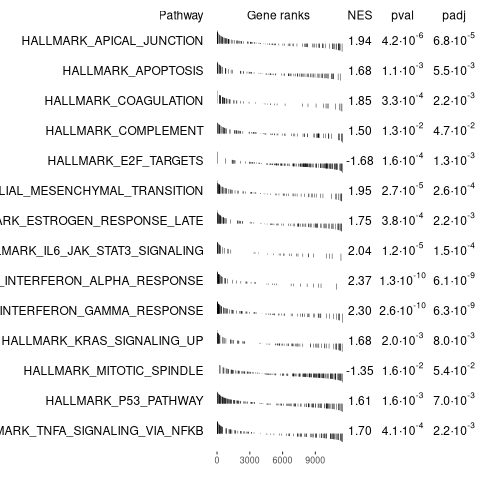

In [26]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL2_significant$pathway], 
              rankings, 
              fgsea_MOL2_significant, 
              gseaParam = 0.5)

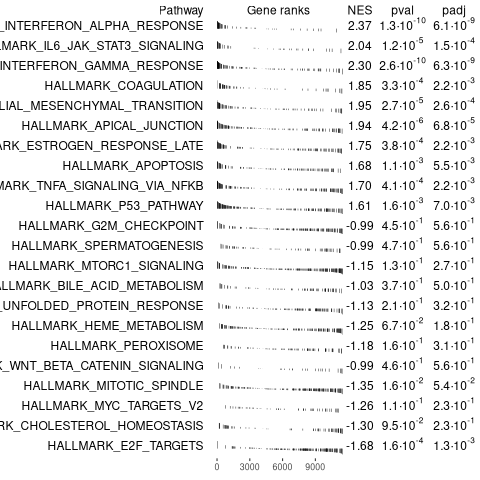

In [27]:
%%R

topUp <- fgsea_res %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)
topDown <- fgsea_res %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)
topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)
plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_res, 
              gseaParam = 0.5)

In [28]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL2_significant[order(pval)][padj < 0.05], 
                                      pathwaysH, rankings)

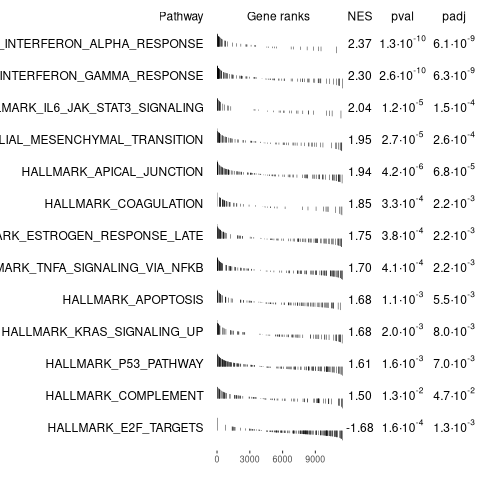

In [29]:
%%R

mainPathways <- fgsea_MOL2_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL2_significant, 
              gseaParam = 0.5)

In [30]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

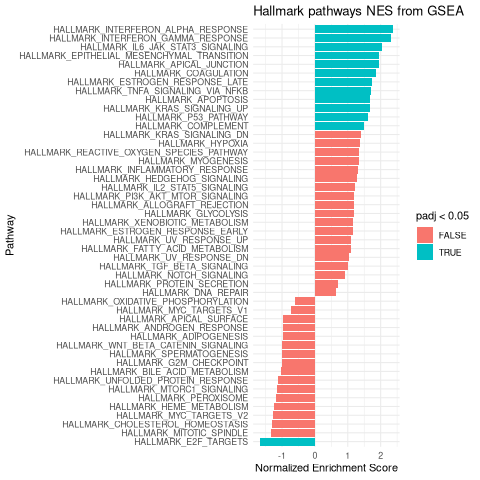

In [31]:
%%R

ggplot(fgseaResTidy, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill=padj<0.05)) +
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",
       title="Hallmark pathways NES from GSEA") + 
  theme_minimal()


#https://stephenturner.github.io/deseq-to-fgsea/#using_the_fgsea_package

In [32]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                             padj   NES  size
  <chr>                                              <dbl> <dbl> <int>
1 HALLMARK_INTERFERON_ALPHA_RESPONSE         0.00000000615  2.37    44
2 HALLMARK_INTERFERON_GAMMA_RESPONSE         0.00000000627  2.30    92
3 HALLMARK_APICAL_JUNCTION                   0.0000679      1.94   112
4 HALLMARK_IL6_JAK_STAT3_SIGNALING           0.000147       2.04    36
5 HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 0.000263       1.95    75
6 HALLMARK_E2F_TARGETS                       0.00125       -1.68   145


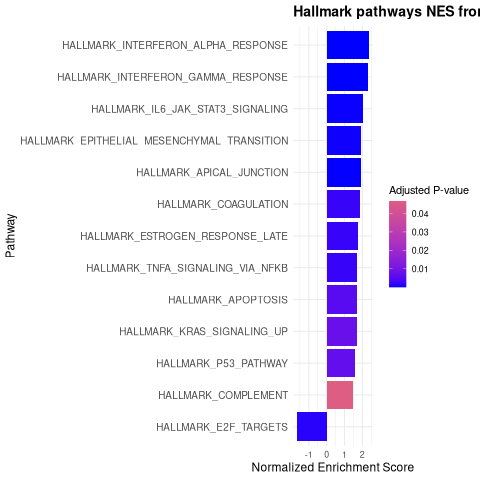

In [33]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

In [34]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                             padj   NES  size
  <chr>                                              <dbl> <dbl> <int>
1 HALLMARK_INTERFERON_ALPHA_RESPONSE         0.00000000615  2.37    44
2 HALLMARK_INTERFERON_GAMMA_RESPONSE         0.00000000627  2.30    92
3 HALLMARK_APICAL_JUNCTION                   0.0000679      1.94   112
4 HALLMARK_IL6_JAK_STAT3_SIGNALING           0.000147       2.04    36
5 HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 0.000263       1.95    75
6 HALLMARK_E2F_TARGETS                       0.00125       -1.68   145


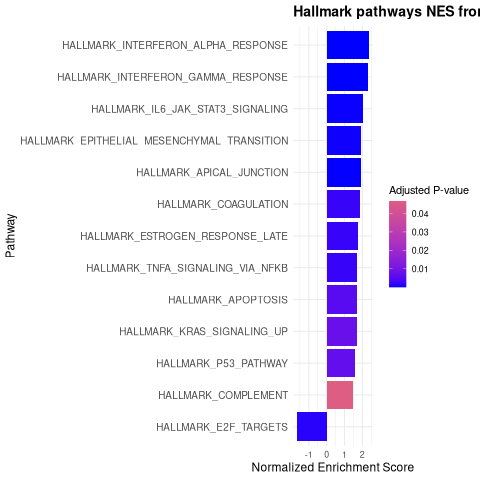

In [35]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )


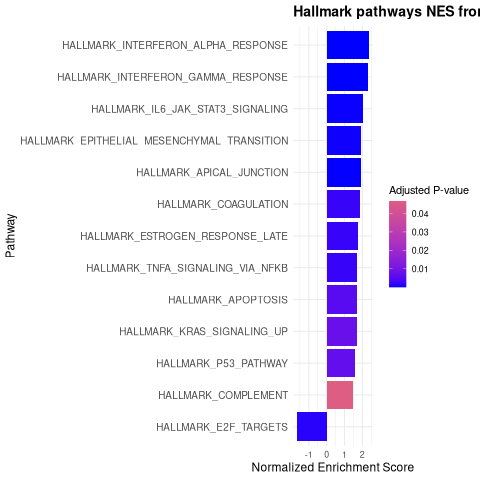

In [36]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/LPC_demyel_MOL_F_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [37]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                    padj   NES  size
  <chr>                                     <dbl> <dbl> <int>
1 INTERFERON_ALPHA_RESPONSE         0.00000000615  2.37    44
2 INTERFERON_GAMMA_RESPONSE         0.00000000627  2.30    92
3 APICAL_JUNCTION                   0.0000679      1.94   112
4 IL6_JAK_STAT3_SIGNALING           0.000147       2.04    36
5 EPITHELIAL_MESENCHYMAL_TRANSITION 0.000263       1.95    75
6 E2F_TARGETS                       0.00125       -1.68   145


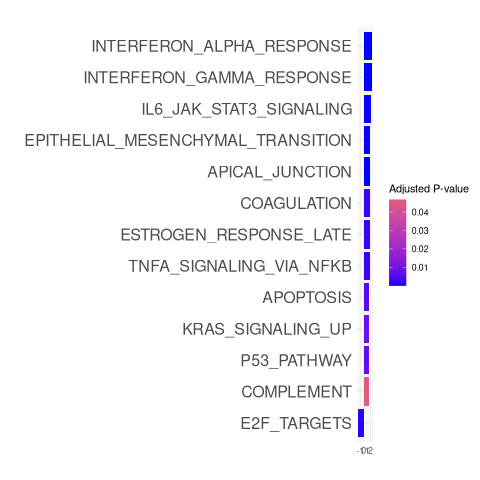

In [38]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 16),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 16, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/LPC_demyel_MOL_hallmark_pathways_NES_GSEA_trimmed.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [39]:
%%R

filtered_fgseaResSignificant_LPC_demyel <- fgsea_MOL2_significant
# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant_LPC_demyel$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant_LPC_demyel$pathway)
head(filtered_fgseaResSignificant_LPC_demyel)

                             pathway         pval         padj   log2err
                              <char>        <num>        <num>     <num>
1:                   APICAL_JUNCTION 4.243412e-06 6.789458e-05 0.6105269
2:                         APOPTOSIS 1.146006e-03 5.500829e-03 0.4550599
3:                       COAGULATION 3.343900e-04 2.178321e-03 0.4984931
4:                        COMPLEMENT 1.265686e-02 4.673302e-02 0.3807304
5:                       E2F_TARGETS 1.562858e-04 1.250286e-03 0.5188481
6: EPITHELIAL_MESENCHYMAL_TRANSITION 2.737962e-05 2.628444e-04 0.5756103
           ES       NES  size                                 leadingEdge
        <num>     <num> <int>                                      <list>
1:  0.5697592  1.939090   112 Col16a1,Ldlrap1,Inppl1,Nrtn,Flnc,Tspan4,...
2:  0.5074908  1.679243    94      Cdkn1a,Irf1,Eno2,Cd44,Lmna,Gadd45a,...
3:  0.6235519  1.850416    50           Pros1,Gsn,Bmp1,Mmp11,Cpq,Klk8,...
4:  0.4544595  1.498915    92       Irf1,Cdh13

In [40]:
%%R
unique(filtered_fgseaResSignificant_LPC_demyel$pathway)

 [1] "APICAL_JUNCTION"                   "APOPTOSIS"                        
 [3] "COAGULATION"                       "COMPLEMENT"                       
 [5] "E2F_TARGETS"                       "EPITHELIAL_MESENCHYMAL_TRANSITION"
 [7] "ESTROGEN_RESPONSE_LATE"            "IL6_JAK_STAT3_SIGNALING"          
 [9] "INTERFERON_ALPHA_RESPONSE"         "INTERFERON_GAMMA_RESPONSE"        
[11] "KRAS_SIGNALING_UP"                 "MITOTIC_SPINDLE"                  
[13] "P53_PATHWAY"                       "TNFA_SIGNALING_VIA_NFKB"          


In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "TNFA_SIGNALING_VIA_NFKB"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_demyel[filtered_fgseaResSignificant_LPC_demyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "INTERFERON_ALPHA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_demyel[filtered_fgseaResSignificant_LPC_demyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "INTERFERON_GAMMA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_demyel[filtered_fgseaResSignificant_LPC_demyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "EPITHELIAL_MESENCHYMAL_TRANSITION"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_demyel[filtered_fgseaResSignificant_LPC_demyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

class(fgsea_MOL2_significant)

In [ ]:
%%R

fgsea_MOL2_significant <- as.data.frame(fgsea_MOL2_significant)

In [41]:
%%R
library(data.table)
fwrite(fgsea_MOL2_significant, file = "./files/filtered_fgseaResSignificant_LPC_demyel_MOL_allgenes.csv")

# LPC_remyel_MOL

In [42]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/LPC_remyel_MOL_all_voom_wqw_UPDATED.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

       gene    logFC  AveExpr        t      P.Value    adj.P.Val         B
1       C4b 5.217222 7.071646 25.72160 1.219612e-10 1.211940e-06 14.992433
2 Serpina3n 5.544546 5.532649 24.67122 1.857522e-10 1.211940e-06 14.464170
3     Cebpd 3.020384 4.685682 17.27082 6.606840e-09 2.873755e-05 11.166383
4     Socs3 6.146866 3.596850 16.09360 1.329511e-08 3.727038e-05 10.223699
5     Anxa2 5.593694 3.502627 15.49230 1.935944e-08 3.727038e-05  9.922841
6      Flnc 3.082891 3.099683 15.47412 1.958472e-08 3.727038e-05 10.024307


In [43]:
%%R

dim(df)

[1] 13049     7


In [44]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "C4b"       "Serpina3n" "Cebpd"     "Socs3"     "Anxa2"     "Flnc"     


In [45]:
%%R
# Check column names in the dataframe
colnames(df)

[1] "gene"      "logFC"     "AveExpr"   "t"         "P.Value"   "adj.P.Val"
[7] "B"        


In [46]:
%%R

# Compute ranking score using all genes
df$ranking_score <- -log10(df$P.Value) * sign(df$logFC)

# Assign gene names
rankings <- df$ranking_score
names(rankings) <- df$gene

# Sort rankings
rankings <- sort(rankings, decreasing = TRUE)

In [47]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


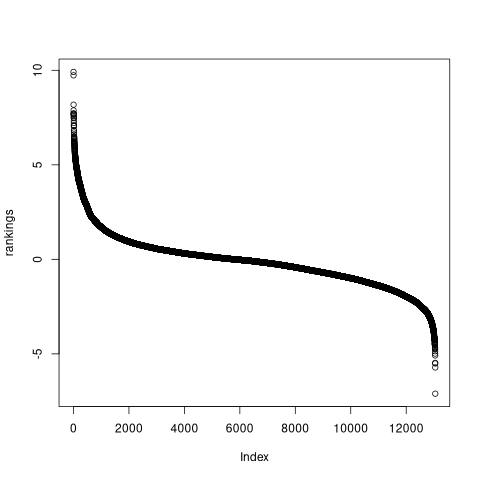

In [48]:
%%R

plot(rankings)

In [49]:
%%R

max(rankings)

[1] 9.913778


In [50]:
%%R

min(rankings)

[1] -7.106214


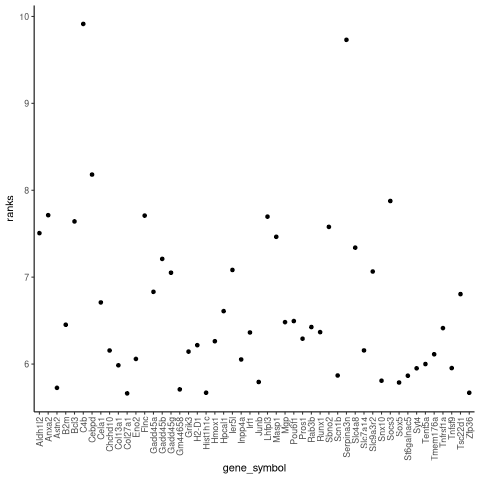

In [51]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Figure out how to set up gene lists

In [52]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [53]:
%%R
fgsea_res

                                       pathway         pval         padj
                                        <char>        <num>        <num>
 1:                      HALLMARK_ADIPOGENESIS 8.353808e-02 1.382699e-01
 2:               HALLMARK_ALLOGRAFT_REJECTION 1.915367e-01 2.704048e-01
 3:                 HALLMARK_ANDROGEN_RESPONSE 6.159292e-01 7.210878e-01
 4:                   HALLMARK_APICAL_JUNCTION 5.003627e-03 1.200870e-02
 5:                    HALLMARK_APICAL_SURFACE 5.565217e-02 1.019509e-01
 6:                         HALLMARK_APOPTOSIS 4.577045e-08 4.393963e-07
 7:              HALLMARK_BILE_ACID_METABOLISM 5.026643e-01 6.186638e-01
 8:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 9.337647e-03 2.037305e-02
 9:                       HALLMARK_COAGULATION 5.308675e-03 1.213411e-02
10:                        HALLMARK_COMPLEMENT 1.805869e-01 2.704048e-01
11:                        HALLMARK_DNA_REPAIR 9.373550e-01 9.572987e-01
12:                       HALLMARK_E2F_TARGETS 8.40

In [54]:
%%R

dim(fgsea_res)

[1] 48  8


In [55]:
%%R

fwrite(fgsea_res, file = "./files/fgsea_LPC_remyel_MOL_allgenes.csv")

In [56]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL2_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL2_significant)

[1] 24  8


In [57]:
%%R

head(fgsea_MOL2_significant)

                                      pathway         pval         padj
                                       <char>        <num>        <num>
1:                   HALLMARK_APICAL_JUNCTION 5.003627e-03 1.200870e-02
2:                         HALLMARK_APOPTOSIS 4.577045e-08 4.393963e-07
3:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 9.337647e-03 2.037305e-02
4:                       HALLMARK_COAGULATION 5.308675e-03 1.213411e-02
5: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 9.015764e-06 5.409459e-05
6:            HALLMARK_ESTROGEN_RESPONSE_LATE 4.499301e-05 2.159664e-04
     log2err         ES       NES  size
       <num>      <num>     <num> <int>
1: 0.4070179  0.3720619  1.484708   120
2: 0.7195128  0.5511985  2.137875   104
3: 0.3807304 -0.4340592 -1.498013    59
4: 0.4070179  0.4573888  1.645289    62
5: 0.5933255  0.5252802  1.987843    88
6: 0.5573322  0.4584684  1.786834   110
                                     leadingEdge
                                          <list>
1:    

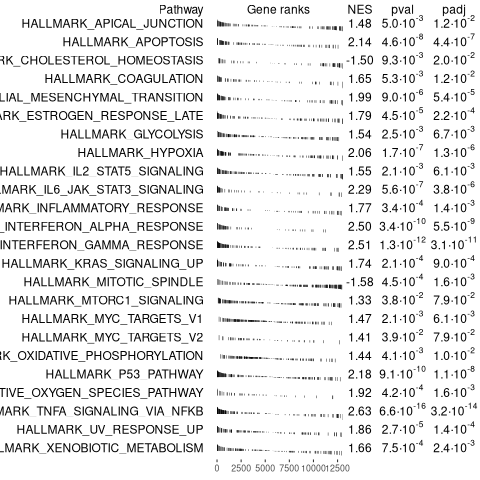

In [58]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL2_significant$pathway], 
              rankings, 
              fgsea_MOL2_significant, 
              gseaParam = 0.5)

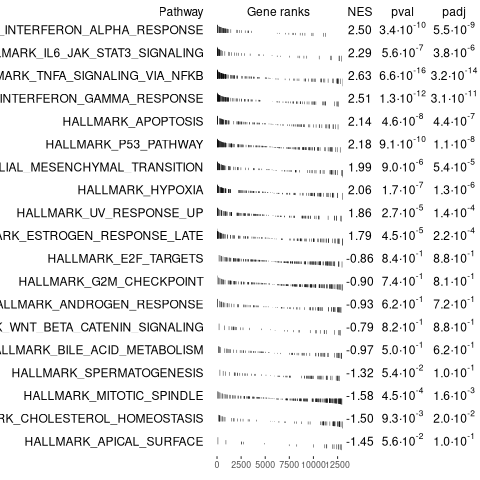

In [59]:
%%R

topUp <- fgsea_res %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)
topDown <- fgsea_res %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)
topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)
plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_res, 
              gseaParam = 0.5)

In [60]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL2_significant[order(pval)][padj < 0.05], 
                                      pathwaysH, rankings)

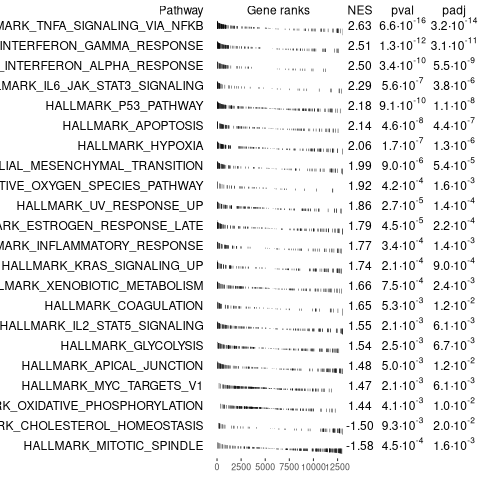

In [61]:
%%R

mainPathways <- fgsea_MOL2_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL2_significant, 
              gseaParam = 0.5)

In [62]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

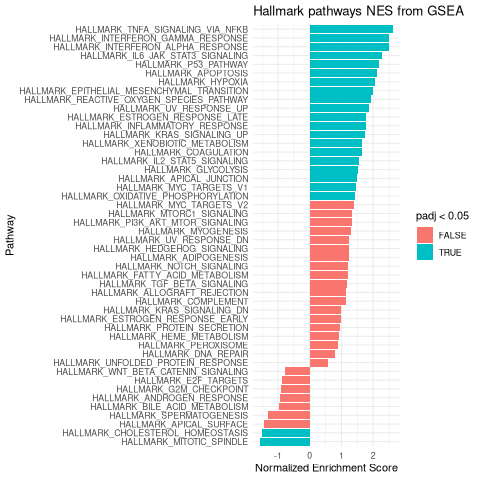

In [63]:
%%R

ggplot(fgseaResTidy, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill=padj<0.05)) +
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",
       title="Hallmark pathways NES from GSEA") + 
  theme_minimal()


#https://stephenturner.github.io/deseq-to-fgsea/#using_the_fgsea_package

In [64]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                padj   NES  size
  <chr>                                 <dbl> <dbl> <int>
1 HALLMARK_TNFA_SIGNALING_VIA_NFKB   3.15e-14  2.63   125
2 HALLMARK_INTERFERON_GAMMA_RESPONSE 3.09e-11  2.51   103
3 HALLMARK_INTERFERON_ALPHA_RESPONSE 5.46e- 9  2.50    49
4 HALLMARK_P53_PATHWAY               1.10e- 8  2.18   152
5 HALLMARK_APOPTOSIS                 4.39e- 7  2.14   104
6 HALLMARK_HYPOXIA                   1.34e- 6  2.06   127


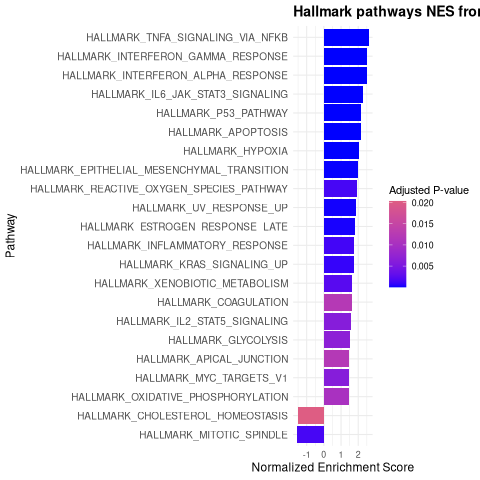

In [65]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

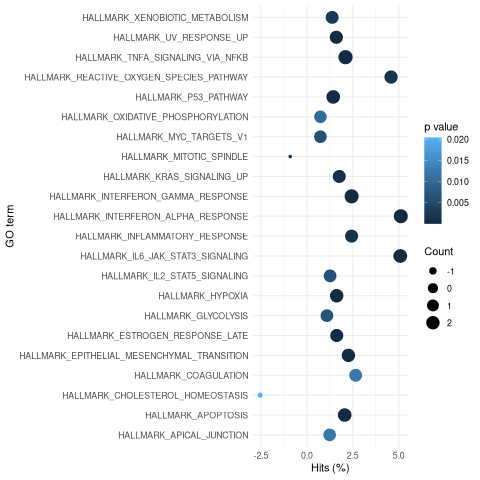

In [66]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [67]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                padj   NES  size
  <chr>                                 <dbl> <dbl> <int>
1 HALLMARK_TNFA_SIGNALING_VIA_NFKB   3.15e-14  2.63   125
2 HALLMARK_INTERFERON_GAMMA_RESPONSE 3.09e-11  2.51   103
3 HALLMARK_INTERFERON_ALPHA_RESPONSE 5.46e- 9  2.50    49
4 HALLMARK_P53_PATHWAY               1.10e- 8  2.18   152
5 HALLMARK_APOPTOSIS                 4.39e- 7  2.14   104
6 HALLMARK_HYPOXIA                   1.34e- 6  2.06   127


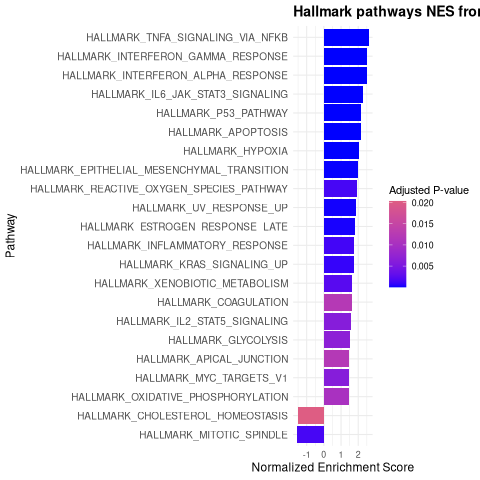

In [68]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )


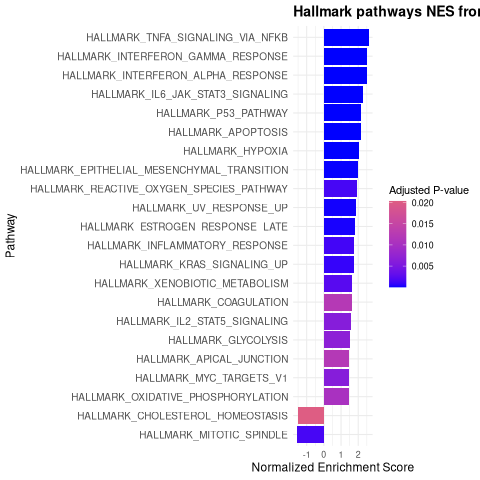

In [69]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/LPC_demyel_MOL_E_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [ ]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

In [ ]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 16),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 16, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/LPC_remyel_MOL_hallmark_pathways_NES_GSEA_trimmed.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [70]:
%%R

filtered_fgseaResSignificant_LPC_demyel <- fgsea_MOL2_significant
# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant_LPC_demyel$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant_LPC_demyel$pathway)
head(filtered_fgseaResSignificant_LPC_demyel)

                             pathway         pval         padj   log2err
                              <char>        <num>        <num>     <num>
1:                   APICAL_JUNCTION 5.003627e-03 1.200870e-02 0.4070179
2:                         APOPTOSIS 4.577045e-08 4.393963e-07 0.7195128
3:           CHOLESTEROL_HOMEOSTASIS 9.337647e-03 2.037305e-02 0.3807304
4:                       COAGULATION 5.308675e-03 1.213411e-02 0.4070179
5: EPITHELIAL_MESENCHYMAL_TRANSITION 9.015764e-06 5.409459e-05 0.5933255
6:            ESTROGEN_RESPONSE_LATE 4.499301e-05 2.159664e-04 0.5573322
           ES       NES  size                                   leadingEdge
        <num>     <num> <int>                                        <list>
1:  0.3720619  1.484708   120         Flnc,Tspan4,Nrtn,Bmp1,Thbs3,Cntn1,...
2:  0.5511985  2.137875   104 Gadd45b,Gadd45a,Irf1,Hmox1,Eno2,Tnfrsf12a,...
3: -0.4340592 -1.498013    59          Alcam,Idi1,Sqle,Tmem97,Lss,Dhcr7,...
4:  0.4573888  1.645289    62       

In [71]:
%%R
unique(filtered_fgseaResSignificant_LPC_demyel$pathway)

 [1] "APICAL_JUNCTION"                   "APOPTOSIS"                        
 [3] "CHOLESTEROL_HOMEOSTASIS"           "COAGULATION"                      
 [5] "EPITHELIAL_MESENCHYMAL_TRANSITION" "ESTROGEN_RESPONSE_LATE"           
 [7] "GLYCOLYSIS"                        "HYPOXIA"                          
 [9] "IL2_STAT5_SIGNALING"               "IL6_JAK_STAT3_SIGNALING"          
[11] "INFLAMMATORY_RESPONSE"             "INTERFERON_ALPHA_RESPONSE"        
[13] "INTERFERON_GAMMA_RESPONSE"         "KRAS_SIGNALING_UP"                
[15] "MITOTIC_SPINDLE"                   "MTORC1_SIGNALING"                 
[17] "MYC_TARGETS_V1"                    "MYC_TARGETS_V2"                   
[19] "OXIDATIVE_PHOSPHORYLATION"         "P53_PATHWAY"                      
[21] "REACTIVE_OXYGEN_SPECIES_PATHWAY"   "TNFA_SIGNALING_VIA_NFKB"          
[23] "UV_RESPONSE_UP"                    "XENOBIOTIC_METABOLISM"            


In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "TNFA_SIGNALING_VIA_NFKB"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_demyel[filtered_fgseaResSignificant_LPC_demyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "INTERFERON_ALPHA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_demyel[filtered_fgseaResSignificant_LPC_demyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "INTERFERON_GAMMA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_demyel[filtered_fgseaResSignificant_LPC_demyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "P53_PATHWAY"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_demyel[filtered_fgseaResSignificant_LPC_demyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "ESTROGEN_RESPONSE_LATE"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_demyel[filtered_fgseaResSignificant_LPC_demyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "IL6_JAK_STAT3_SIGNALING"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_demyel[filtered_fgseaResSignificant_LPC_demyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "INFLAMMATORY_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_demyel[filtered_fgseaResSignificant_LPC_demyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

class(fgsea_MOL2_significant)

In [ ]:
%%R

fgsea_MOL2_significant <- as.data.frame(fgsea_MOL2_significant)

In [72]:
%%R
library(data.table)
fwrite(fgsea_MOL2_significant, file = "./files/filtered_fgseaResSignificant_LPC_remyel_MOL_allgenes.csv")

# Cupr_demyel_MOL

In [73]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/Cupr_demyel_MOL_all_voom_wqw_UPDATED.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

    gene    logFC  AveExpr        t      P.Value    adj.P.Val        B
1  Nupr1 4.898026 5.078916 37.40949 1.055845e-14 1.112438e-10 23.87234
2  Tenm4 4.200487 6.070549 32.30929 7.063138e-14 3.720861e-10 22.16658
3 Cyb5r2 3.999251 3.559794 31.21058 1.105228e-13 3.881561e-10 21.51275
4 Cdkn1a 8.380500 6.432924 27.74343 5.058080e-13 1.034066e-09 20.30639
5 Col5a3 5.436127 2.727176 27.69438 5.174823e-13 1.034066e-09 19.60116
6    Btc 3.251113 3.061384 27.41812 5.888756e-13 1.034066e-09 20.00548


In [74]:
%%R

dim(df)

[1] 10536     7


In [75]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "Nupr1"  "Tenm4"  "Cyb5r2" "Cdkn1a" "Col5a3" "Btc"   


In [76]:
%%R
# Check column names in the dataframe
colnames(df)

[1] "gene"      "logFC"     "AveExpr"   "t"         "P.Value"   "adj.P.Val"
[7] "B"        


In [78]:
%%R

# Compute ranking score: sign(logFC) * -log10(P.Value)
df$ranking_score <- sign(df$logFC) * -log10(df$P.Value)

# Assign names to the rankings
rankings <- df$ranking_score
names(rankings) <- df$gene

# Sort the rankings in descending order
rankings <- sort(rankings, decreasing = TRUE)

In [79]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


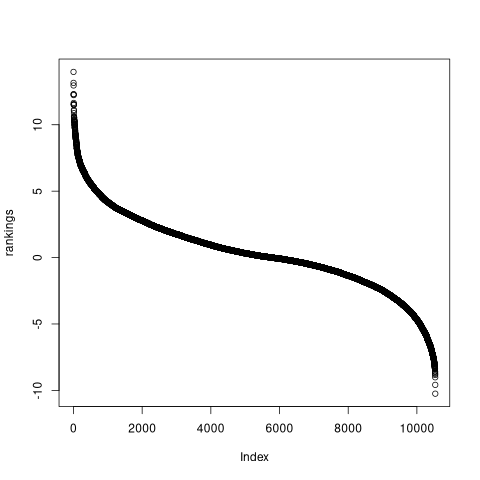

In [80]:
%%R

plot(rankings)

In [81]:
%%R

max(rankings)

[1] 13.9764


In [82]:
%%R

min(rankings)

[1] -10.24865


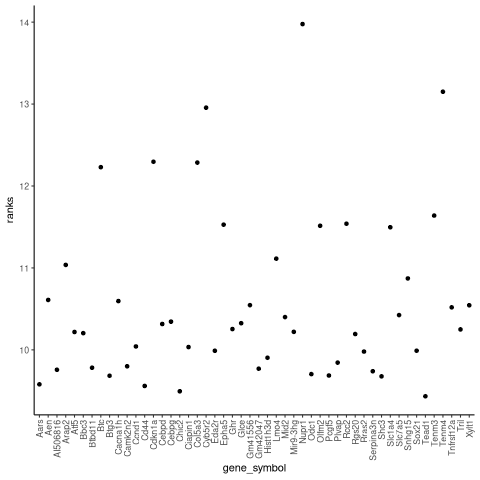

In [83]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Set up gene lists

In [84]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [85]:
%%R
fgsea_res

                                       pathway         pval         padj
                                        <char>        <num>        <num>
 1:                      HALLMARK_ADIPOGENESIS 6.824645e-01 7.637102e-01
 2:               HALLMARK_ALLOGRAFT_REJECTION 7.302726e-01 7.800639e-01
 3:                 HALLMARK_ANDROGEN_RESPONSE 5.034722e-01 5.915799e-01
 4:                   HALLMARK_APICAL_JUNCTION 1.061202e-02 3.143562e-02
 5:                         HALLMARK_APOPTOSIS 2.886209e-03 1.090279e-02
 6:              HALLMARK_BILE_ACID_METABOLISM 2.117264e-01 3.119209e-01
 7:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 2.028984e-02 4.768112e-02
 8:                       HALLMARK_COAGULATION 3.403298e-01 4.443195e-01
 9:                        HALLMARK_COMPLEMENT 2.190083e-01 3.119209e-01
10:                        HALLMARK_DNA_REPAIR 1.781882e-05 1.395808e-04
11:                       HALLMARK_E2F_TARGETS 1.120290e-04 7.521948e-04
12: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 3.42

In [86]:
%%R

dim(fgsea_res)

[1] 47  8


In [87]:
%%R

fwrite(fgsea_res, file = "./files/fgsea_Cupr_demyel_MOL_allgenes.csv")

In [88]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL4_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL4_significant)

[1] 23  8


In [89]:
%%R

head(fgsea_MOL4_significant)

                                      pathway         pval         padj
                                       <char>        <num>        <num>
1:                   HALLMARK_APICAL_JUNCTION 1.061202e-02 0.0314356159
2:                         HALLMARK_APOPTOSIS 2.886209e-03 0.0109027910
3:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 2.028984e-02 0.0476811161
4:                        HALLMARK_DNA_REPAIR 1.781882e-05 0.0001395808
5:                       HALLMARK_E2F_TARGETS 1.120290e-04 0.0007521948
6: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 3.426289e-03 0.0115025401
     log2err         ES       NES  size
       <num>      <num>     <num> <int>
1: 0.3807304 -0.3328650 -1.403168   105
2: 0.4317077  0.4356798  1.591015    91
3: 0.3524879 -0.3905110 -1.462231    54
4: 0.5756103  0.4665506  1.808335   135
5: 0.5384341  0.4448856  1.724362   135
6: 0.4317077  0.4564382  1.598826    68
                                       leadingEdge
                                            <list>
1:

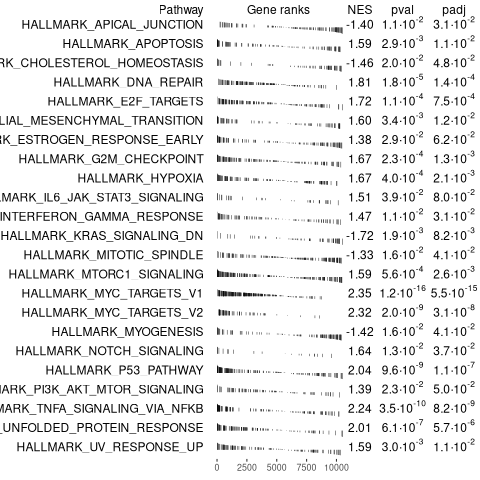

In [90]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL4_significant$pathway], 
              rankings, 
              fgsea_MOL4_significant, 
              gseaParam = 0.5)

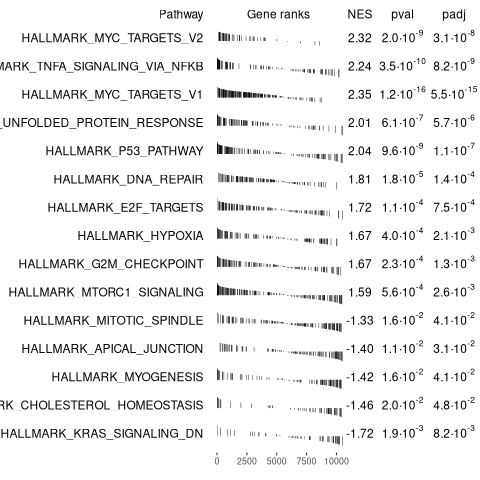

In [91]:
%%R

topUp <- fgsea_MOL4_significant %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)

topDown <- fgsea_MOL4_significant %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)

topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)

plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_MOL4_significant, 
              gseaParam = 0.5)

In [92]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL4_significant[order(pval)][padj < 0.05], 
                                      pathwaysH, rankings)

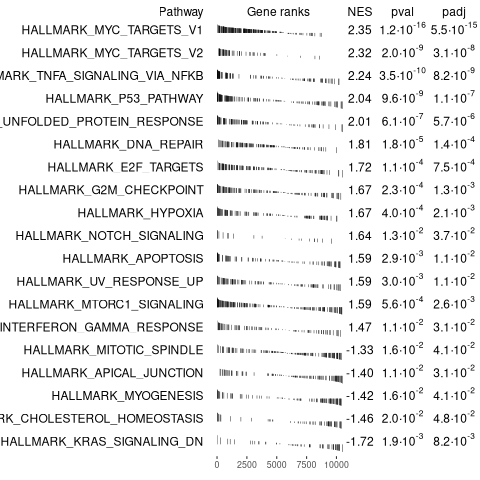

In [93]:
%%R

mainPathways <- fgsea_MOL4_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL4_significant, 
              gseaParam = 0.5)

In [94]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

In [95]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                padj   NES  size
  <chr>                                 <dbl> <dbl> <int>
1 HALLMARK_MYC_TARGETS_V1            5.49e-15  2.35   191
2 HALLMARK_TNFA_SIGNALING_VIA_NFKB   8.15e- 9  2.24    99
3 HALLMARK_MYC_TARGETS_V2            3.09e- 8  2.32    51
4 HALLMARK_P53_PATHWAY               1.13e- 7  2.04   131
5 HALLMARK_UNFOLDED_PROTEIN_RESPONSE 5.74e- 6  2.01    99
6 HALLMARK_DNA_REPAIR                1.40e- 4  1.81   135


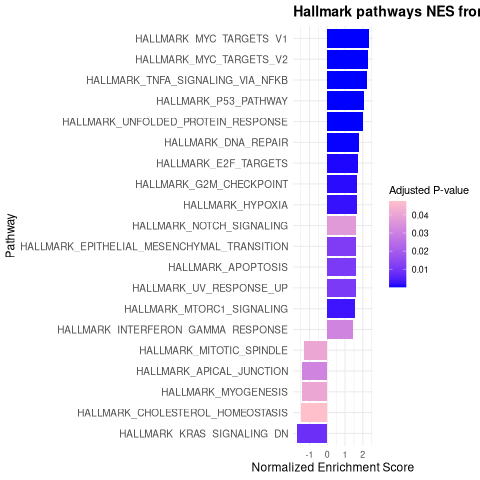

In [96]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "blue", high = "pink", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

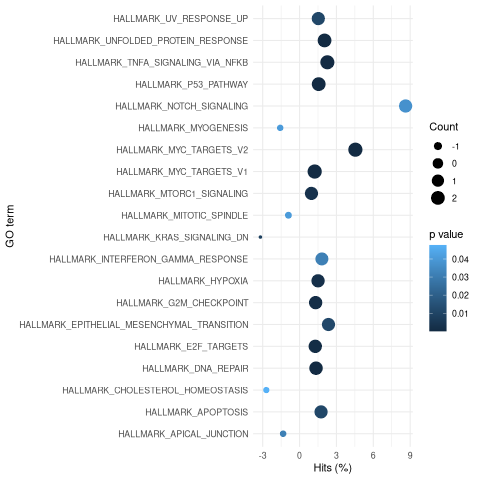

In [97]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [98]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                padj   NES  size
  <chr>                                 <dbl> <dbl> <int>
1 HALLMARK_MYC_TARGETS_V1            5.49e-15  2.35   191
2 HALLMARK_TNFA_SIGNALING_VIA_NFKB   8.15e- 9  2.24    99
3 HALLMARK_MYC_TARGETS_V2            3.09e- 8  2.32    51
4 HALLMARK_P53_PATHWAY               1.13e- 7  2.04   131
5 HALLMARK_UNFOLDED_PROTEIN_RESPONSE 5.74e- 6  2.01    99
6 HALLMARK_DNA_REPAIR                1.40e- 4  1.81   135


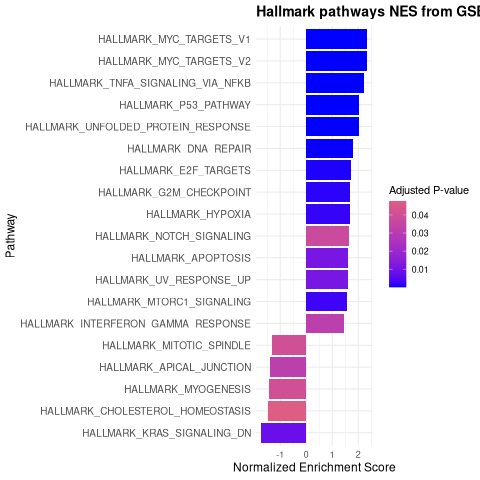

In [99]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )


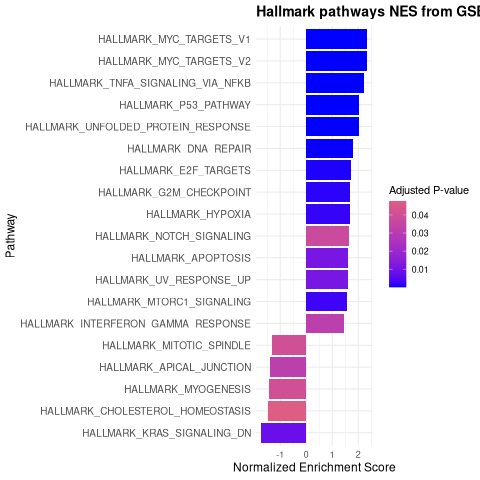

In [100]:
%%R

# Create the ggplot
plot <- # Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/Cupr_demyel_MOL_G_reduced_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [101]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                       padj   NES  size
  <chr>                        <dbl> <dbl> <int>
1 MYC_TARGETS_V1            5.49e-15  2.35   191
2 TNFA_SIGNALING_VIA_NFKB   8.15e- 9  2.24    99
3 MYC_TARGETS_V2            3.09e- 8  2.32    51
4 P53_PATHWAY               1.13e- 7  2.04   131
5 UNFOLDED_PROTEIN_RESPONSE 5.74e- 6  2.01    99
6 DNA_REPAIR                1.40e- 4  1.81   135


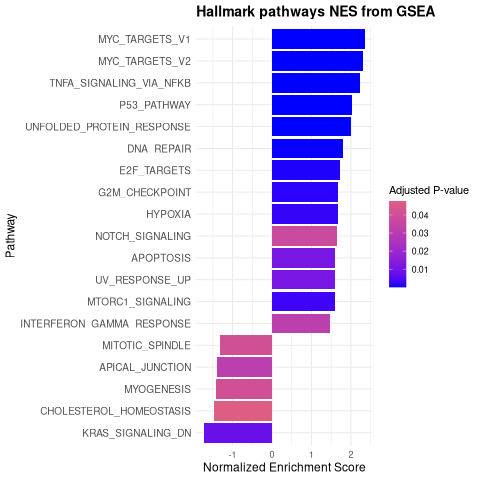

In [102]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/LPC_remyel_MOL_hallmark_pathways_NES_GSEA_trimmed.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

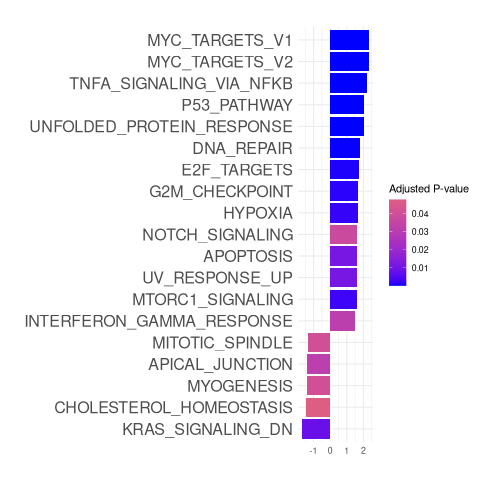

In [103]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 16),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 16, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/Cupr_demyel_MOL_reduced_hallmark_pathways_NES_GSEA_trimmed.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [ ]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Calculate hits percentage
filtered_fgseaResSignificant <- filtered_fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
filtered_fgseaResSignificant <- filtered_fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(filtered_fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()


In [104]:
%%R

filtered_fgseaResSignificant_LPC_remyel <- fgsea_MOL4_significant
# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant_LPC_remyel$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant_LPC_remyel$pathway)
head(filtered_fgseaResSignificant_LPC_remyel)

                             pathway         pval         padj   log2err
                              <char>        <num>        <num>     <num>
1:                   APICAL_JUNCTION 1.061202e-02 0.0314356159 0.3807304
2:                         APOPTOSIS 2.886209e-03 0.0109027910 0.4317077
3:           CHOLESTEROL_HOMEOSTASIS 2.028984e-02 0.0476811161 0.3524879
4:                        DNA_REPAIR 1.781882e-05 0.0001395808 0.5756103
5:                       E2F_TARGETS 1.120290e-04 0.0007521948 0.5384341
6: EPITHELIAL_MESENCHYMAL_TRANSITION 3.426289e-03 0.0115025401 0.4317077
           ES       NES  size                                     leadingEdge
        <num>     <num> <int>                                          <list>
1: -0.3328650 -1.403168   105 Ppp2r2c,Insig1,Itgb4,Nectin1,Shroom2,Cercam,...
2:  0.4356798  1.591015    91      Cdkn1a,Tnfrsf12a,Ccnd1,Btg3,Cd44,Ddit3,...
3: -0.3905110 -1.462231    54            Abca2,Scd2,Fasn,Fdft1,Scd1,Gnai1,...
4:  0.4665506  1.808335   

In [105]:
%%R
unique(filtered_fgseaResSignificant_LPC_remyel$pathway)

 [1] "APICAL_JUNCTION"                   "APOPTOSIS"                        
 [3] "CHOLESTEROL_HOMEOSTASIS"           "DNA_REPAIR"                       
 [5] "E2F_TARGETS"                       "EPITHELIAL_MESENCHYMAL_TRANSITION"
 [7] "ESTROGEN_RESPONSE_EARLY"           "G2M_CHECKPOINT"                   
 [9] "HYPOXIA"                           "IL6_JAK_STAT3_SIGNALING"          
[11] "INTERFERON_GAMMA_RESPONSE"         "KRAS_SIGNALING_DN"                
[13] "MITOTIC_SPINDLE"                   "MTORC1_SIGNALING"                 
[15] "MYC_TARGETS_V1"                    "MYC_TARGETS_V2"                   
[17] "MYOGENESIS"                        "NOTCH_SIGNALING"                  
[19] "P53_PATHWAY"                       "PI3K_AKT_MTOR_SIGNALING"          
[21] "TNFA_SIGNALING_VIA_NFKB"           "UNFOLDED_PROTEIN_RESPONSE"        
[23] "UV_RESPONSE_UP"                   


In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "TNFA_SIGNALING_VIA_NFKB"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_remyel[filtered_fgseaResSignificant_LPC_remyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "INTERFERON_ALPHA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_remyel[filtered_fgseaResSignificant_LPC_remyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "INTERFERON_GAMMA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_remyel[filtered_fgseaResSignificant_LPC_remyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "IL6_JAK_STAT3_SIGNALING"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_remyel[filtered_fgseaResSignificant_LPC_remyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "INFLAMMATORY_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_remyel[filtered_fgseaResSignificant_LPC_remyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "CHOLESTEROL_HOMEOSTASIS"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_remyel[filtered_fgseaResSignificant_LPC_remyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "ESTROGEN_RESPONSE_LATE"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_remyel[filtered_fgseaResSignificant_LPC_remyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "P53_PATHWAY"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgseaResSignificant_LPC_remyel[filtered_fgseaResSignificant_LPC_remyel$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

class(fgsea_MOL4_significant)

In [ ]:
%%R

fgsea_MOL4_significant <- as.data.frame(fgsea_MOL4_significant)

In [106]:
%%R
library(data.table)
fwrite(fgsea_MOL4_significant, file = "./files/filtered_fgseaResSignificant_Cupr_demyel_MOL_allgenes.csv")

# Combined dot plot

In [ ]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import random
import sc_toolbox
import pertpy 

import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

pd.set_option('display.max_columns', None)

%load_ext rpy2.ipython

In [ ]:
%%R
library(GSA)
library(msigdbr)
library(fgsea)
library(data.table)
library(tidyverse) # includes ggplot2, for data visualisation. dplyr, for data manipulation.
library(RColorBrewer) # for a colourful plot

In [ ]:
%%R

set.seed(42)

In [139]:
%%R

# Load the data.table package
library(data.table)

# Read the files back into R
#OPC_de <- fread("./files/filtered_fgseaResSignificant_LPC_demyel_OPC_NEW.csv")
LPC_de <- fread("./files/filtered_fgseaResSignificant_LPC_demyel_MOL_allgenes.csv")
LPC_re <- fread("./files/filtered_fgseaResSignificant_LPC_remyel_MOL_allgenes.csv")
Cupr_de <- fread("./files/filtered_fgseaResSignificant_Cupr_demyel_MOL_allgenes.csv")
#Cupr_re_E <- fread("./files/filtered_fgseaResSignificant_Cupr_remyel_MOL_E.csv")

In [140]:
%%R
dim(LPC_de)

[1] 14  8


In [141]:
%%R
dim(LPC_re)

[1] 24  8


In [142]:
%%R
dim(Cupr_de)

[1] 23  8


In [143]:
%%R

# Subset the data frames to include only pathway, padj, NES, and size
subset_columns <- c("pathway", "NES", "padj")

#OPC_de_subset <- OPC_de[, ..subset_columns]
#OPC_de_subset <- OPC_de[, ..subset_columns]
LPC_de_subset <- LPC_de[, ..subset_columns]
LPC_re_subset <- LPC_re[, ..subset_columns]
Cupr_de_subset <- Cupr_de[, ..subset_columns]
#Cupr_re_E_subset <- Cupr_re_E[, ..subset_columns]

In [144]:
%%R

# Combine the 'pathway' columns from all the data frames
all_pathways <- unique(c(LPC_de$pathway,
                        LPC_re$pathway, Cupr_de$pathway))

# Verify the unique pathways
print(head(all_pathways))

# Check the total number of unique pathways
length(all_pathways)

[1] "HALLMARK_APICAL_JUNCTION"                  
[2] "HALLMARK_APOPTOSIS"                        
[3] "HALLMARK_COAGULATION"                      
[4] "HALLMARK_COMPLEMENT"                       
[5] "HALLMARK_E2F_TARGETS"                      
[6] "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION"
[1] 34


In [145]:
%%R
# Function to ensure each data frame includes all pathways and fills missing ones with NaN
fill_missing_pathways <- function(df, all_pathways) {
  # Identify pathways that are missing in the current data frame
  missing_pathways <- setdiff(all_pathways, df$pathway)
  
  # Create a data frame with missing pathways, NES and padj set to NaN
  missing_data <- data.frame(pathway = missing_pathways, 
                             NES = rep(NaN, length(missing_pathways)), 
                             padj = rep(NaN, length(missing_pathways)))
  
  # Combine the original data frame with the missing pathways
  df <- rbind(df[, c("pathway", "NES", "padj")], missing_data)
  
  # Sort by pathway to maintain a consistent order
  df <- df[order(df$pathway), ]
  
  return(df)
}

# List of all unique pathways
# Combine the 'pathway' columns from all the data frames
all_pathways <- unique(c(LPC_de$pathway,
                        LPC_re$pathway, Cupr_de$pathway))

# Apply the function to all data frames
#OPC_de_filtered <- fill_missing_pathways(OPC_de_subset, all_pathways)
#LPC_de_F_filtered <- fill_missing_pathways(LPC_de_F_subset, all_pathways)
LPC_de_filtered <- fill_missing_pathways(LPC_de_subset, all_pathways)
LPC_re_filtered <- fill_missing_pathways(LPC_re_subset, all_pathways)
Cupr_de_filtered <- fill_missing_pathways(Cupr_de_subset, all_pathways)
#Cupr_re_E_filtered <- fill_missing_pathways(Cupr_re_E_subset, all_pathways)

In [146]:
%%R

head(Cupr_de_filtered)

                            pathway       NES         padj
                             <char>     <num>        <num>
1:         HALLMARK_APICAL_JUNCTION -1.403168 0.0314356159
2:               HALLMARK_APOPTOSIS  1.591015 0.0109027910
3: HALLMARK_CHOLESTEROL_HOMEOSTASIS -1.462231 0.0476811161
4:             HALLMARK_COAGULATION       NaN          NaN
5:              HALLMARK_COMPLEMENT       NaN          NaN
6:              HALLMARK_DNA_REPAIR  1.808335 0.0001395808


In [147]:
%%R

#OPC_de_filtered$condition <- "LPC_de_OPC"
#LPC_de_F_filtered$condition <- "LPC_de_MOL_F"
LPC_de_filtered$condition <- "LPC_demyel"
LPC_re_filtered$condition <- "LPC_remyel"
Cupr_de_filtered$condition <- "CPZ_demyel"
#Cupr_re_E_filtered$condition <- "Cupr_re_MOL_E"

# Combine all datasets into a single dataframe
combined_df <- rbind(LPC_de_filtered,
                    LPC_re_filtered, Cupr_de_filtered)

# Verify the structure
head(combined_df)

                            pathway      NES         padj  condition
                             <char>    <num>        <num>     <char>
1:         HALLMARK_APICAL_JUNCTION 1.939090 6.789458e-05 LPC_demyel
2:               HALLMARK_APOPTOSIS 1.679243 5.500829e-03 LPC_demyel
3: HALLMARK_CHOLESTEROL_HOMEOSTASIS      NaN          NaN LPC_demyel
4:             HALLMARK_COAGULATION 1.850416 2.178321e-03 LPC_demyel
5:              HALLMARK_COMPLEMENT 1.498915 4.673302e-02 LPC_demyel
6:              HALLMARK_DNA_REPAIR      NaN          NaN LPC_demyel


In [148]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
combined_df$pathway <- gsub("^HALLMARK_", "", combined_df$pathway)

# View the updated heatmap_df
head(combined_df)

                   pathway      NES         padj  condition
                    <char>    <num>        <num>     <char>
1:         APICAL_JUNCTION 1.939090 6.789458e-05 LPC_demyel
2:               APOPTOSIS 1.679243 5.500829e-03 LPC_demyel
3: CHOLESTEROL_HOMEOSTASIS      NaN          NaN LPC_demyel
4:             COAGULATION 1.850416 2.178321e-03 LPC_demyel
5:              COMPLEMENT 1.498915 4.673302e-02 LPC_demyel
6:              DNA_REPAIR      NaN          NaN LPC_demyel


In [149]:
%%R

# Transform padj to -log10 for better visualization
combined_df$log_padj <- -log10(combined_df$padj)

In [150]:
%%R
summary(combined_df[, c("condition", "pathway", "log_padj", "NES")])

  condition           pathway             log_padj           NES        
 Length:102         Length:102         Min.   : 1.097   Min.   :-1.721  
 Class :character   Class :character   1st Qu.: 1.921   1st Qu.: 1.470  
 Mode  :character   Mode  :character   Median : 2.662   Median : 1.674  
                                       Mean   : 3.695   Mean   : 1.335  
                                       3rd Qu.: 4.168   3rd Qu.: 1.988  
                                       Max.   :14.261   Max.   : 2.626  
                                       NA's   :41       NA's   :41      


In addition: Warning message:
Removed 41 rows containing missing values or values outside the scale range
(`geom_point()`). 


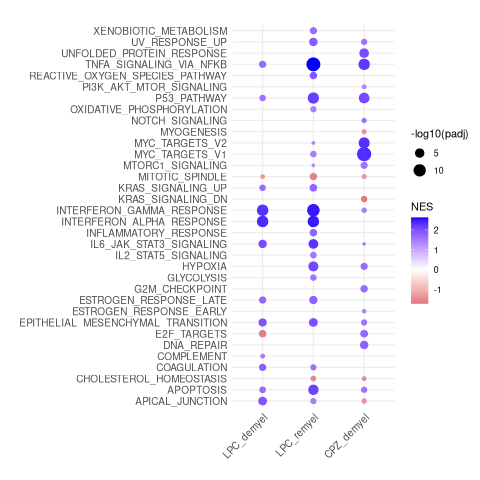

In [151]:
%%R

library(ggplot2)

# Set the factor levels for conditions to control the order
combined_df$condition <- factor(combined_df$condition, 
                                 levels = c("LPC_demyel",
                                           "LPC_remyel", "CPZ_demyel"))

# Create the dotplot with switched axes and assign to heatmap_plot
heatmap_plot <- ggplot(combined_df, aes(y = pathway, x = condition, size = log_padj, color = NES)) +
  geom_point() +
  scale_color_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 10), # Adjust pathway text size for readability
        axis.text.x = element_text(angle = 45, hjust = 1, size = 10)) + # Adjust condition text
  labs(x = "", y = "", 
       size = "-log10(padj)", color = "NES", 
       title = "")

# Show the plot
print(heatmap_plot)

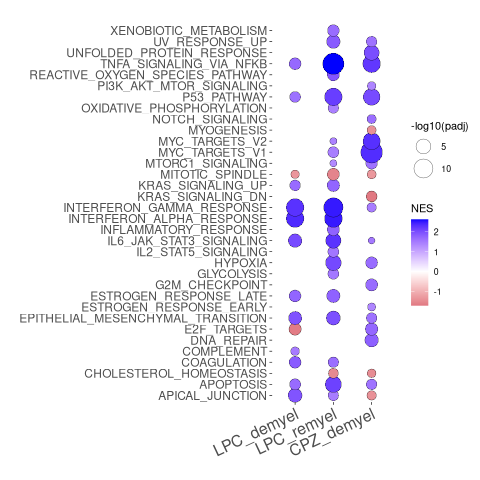

In [152]:
%%R

# Remove rows with missing or NaN values in `log_padj` or `NES`
filtered_df <- combined_df[!is.na(combined_df$log_padj) & !is.na(combined_df$NES), ]

# Set the factor levels for conditions to control the order
combined_df$condition <- factor(combined_df$condition, 
                                 levels = c("LPC_demyel",
                                           "LPC_remyel", "CPZ_demyel"))

# Create the dotplot with adjustments
heatmap_plot <- ggplot(filtered_df, aes(y = pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") + # Add thin black outline to dots
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(3, 10)) + # Increase size of dots (min=3, max=10)
  theme_minimal() +
  theme(
    panel.grid = element_blank(), # Remove grid lines
    axis.text.y = element_text(size = 12), # Adjust pathway text size
    axis.text.x = element_text(angle = 25, hjust = 1, size = 16, vjust = 1), # Adjust x-axis text spacing
    axis.ticks = element_line(linewidth = 0.3) # Adjust x-axis ticks with `linewidth`
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

# Display the plot
print(heatmap_plot)

# Save the plot
#ggsave("./figures/GSEA/heatmap_pathway_NES_padj_ALL_only.png", plot = heatmap_plot, dpi = 300, width = 10, height = 8)

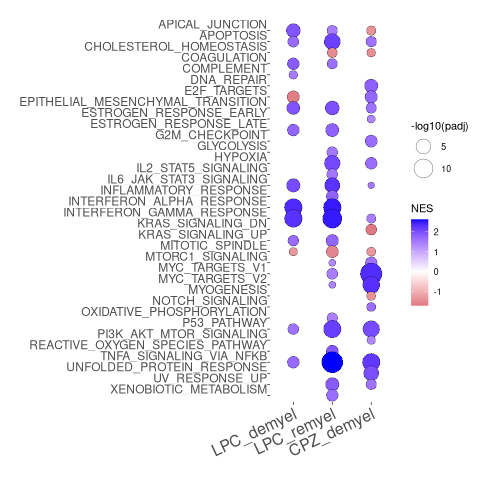

In [153]:
%%R

# Create the dotplot with adjustments
heatmap_plot <- ggplot(filtered_df, aes(y = pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") + # Add thin black outline to dots
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(3, 10)) + # Increase size of dots (min=3, max=10)
  scale_y_discrete(limits = rev(levels(factor(filtered_df$pathway))),  # Reverse the y-axis order if needed
                   labels = function(x) paste0(x, "\n")) + # Add line breaks for extra vertical space
  theme_minimal() +
  theme(
    panel.grid = element_blank(), # Remove grid lines
    axis.text.y = element_text(size = 12, margin = margin(t = 5, b = 5)), # Add vertical spacing for y-axis text
    axis.text.x = element_text(angle = 25, hjust = 1, size = 16, vjust = 1), # Adjust x-axis text spacing
    axis.ticks = element_line(linewidth = 0.3) # Adjust x-axis ticks with `linewidth`
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

# Display the plot
print(heatmap_plot)

# Save the plot
#ggsave("./figures/GSEA/heatmap_pathway_NES_padj_ALL_only.png", plot = heatmap_plot, dpi = 300, width = 10, height = 8)

In [154]:
%%R

pathway_order <- filtered_df %>%
  group_by(pathway) %>%
  summarise(
    n_up = sum(NES > 0),      # number of conditions where NES > 0
    n_down = sum(NES < 0)     # optional, if you care about downregulated too
  ) %>%
  arrange(desc(n_up))         # order pathways by how many are "up"

In [155]:
%%R
filtered_df <- filtered_df %>%
  mutate(pathway = factor(pathway, levels = pathway_order$pathway))

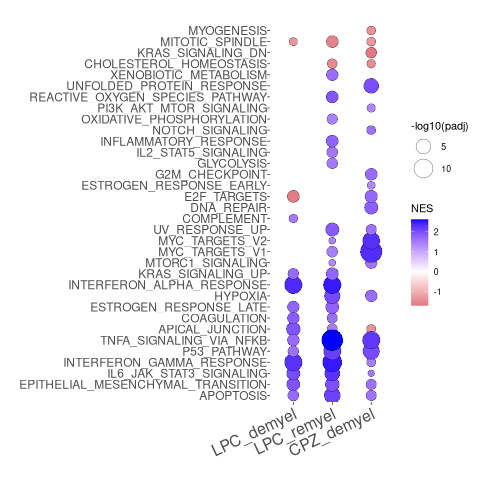

In [156]:
%%R
heatmap_plot <- ggplot(filtered_df, aes(y = pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") +
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(3, 10)) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_text(size = 12, margin = margin(t = 5, b = 5)),
    axis.text.x = element_text(angle = 25, hjust = 1, size = 16, vjust = 1),
    axis.ticks = element_line(linewidth = 0.3)
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

print(heatmap_plot)

In [157]:
%%R
# Or, if you just want the ordered names:
ordered_pathways <- pathway_order$pathway
print(ordered_pathways)

 [1] "APOPTOSIS"                         "EPITHELIAL_MESENCHYMAL_TRANSITION"
 [3] "IL6_JAK_STAT3_SIGNALING"           "INTERFERON_GAMMA_RESPONSE"        
 [5] "P53_PATHWAY"                       "TNFA_SIGNALING_VIA_NFKB"          
 [7] "APICAL_JUNCTION"                   "COAGULATION"                      
 [9] "ESTROGEN_RESPONSE_LATE"            "HYPOXIA"                          
[11] "INTERFERON_ALPHA_RESPONSE"         "KRAS_SIGNALING_UP"                
[13] "MTORC1_SIGNALING"                  "MYC_TARGETS_V1"                   
[15] "MYC_TARGETS_V2"                    "UV_RESPONSE_UP"                   
[17] "COMPLEMENT"                        "DNA_REPAIR"                       
[19] "E2F_TARGETS"                       "ESTROGEN_RESPONSE_EARLY"          
[21] "G2M_CHECKPOINT"                    "GLYCOLYSIS"                       
[23] "IL2_STAT5_SIGNALING"               "INFLAMMATORY_RESPONSE"            
[25] "NOTCH_SIGNALING"                   "OXIDATIVE_PHOSPHORYLATION"        

In [158]:
%%R

# Define the desired order for the "pathways"
desired_pathway_order <- c(
  "INTERFERON_GAMMA_RESPONSE",
  "TNFA_SIGNALING_VIA_NFKB",
  "P53_PATHWAY",
  "APOPTOSIS",
  "EPITHELIAL_MESENCHYMAL_TRANSITION",
  "IL6_JAK_STAT3_SIGNALING",
  "APICAL_JUNCTION",
  "INTERFERON_ALPHA_RESPONSE",
  "KRAS_SIGNALING_UP",
  "ESTROGEN_RESPONSE_LATE",
  "COAGULATION",
  "MYC_TARGETS_V1",
  "MYC_TARGETS_V2",
  "HYPOXIA",
  "UV_RESPONSE_UP",
  "MTORC1_SIGNALING",
  "E2F_TARGETS",
  "COMPLEMENT",
  "OXIDATIVE_PHOSPHORYLATION",
  "IL2_STAT5_SIGNALING",
  "INFLAMMATORY_RESPONSE",
  "GLYCOLYSIS",
  "REACTIVE_OXYGEN_SPECIES_PATHWAY",
  "XENOBIOTIC_METABOLISM",
  "UNFOLDED_PROTEIN_RESPONSE",
    "DNA_REPAIR",
  "G2M_CHECKPOINT",
  "PI3K_AKT_MTOR_SIGNALING",
  "NOTCH_SIGNALING",
  "ESTROGEN_RESPONSE_EARLY",
  "MITOTIC_SPINDLE",
  "CHOLESTEROL_HOMEOSTASIS",
  "KRAS_SIGNALING_DN",
  "MYOGENESIS"
)

# Reorder the 'pathway' column in filtered_df
filtered_df$pathway <- factor(filtered_df$pathway, levels = desired_pathway_order)

# Verify the order
print(levels(filtered_df$pathway))

 [1] "INTERFERON_GAMMA_RESPONSE"         "TNFA_SIGNALING_VIA_NFKB"          
 [3] "P53_PATHWAY"                       "APOPTOSIS"                        
 [5] "EPITHELIAL_MESENCHYMAL_TRANSITION" "IL6_JAK_STAT3_SIGNALING"          
 [7] "APICAL_JUNCTION"                   "INTERFERON_ALPHA_RESPONSE"        
 [9] "KRAS_SIGNALING_UP"                 "ESTROGEN_RESPONSE_LATE"           
[11] "COAGULATION"                       "MYC_TARGETS_V1"                   
[13] "MYC_TARGETS_V2"                    "HYPOXIA"                          
[15] "UV_RESPONSE_UP"                    "MTORC1_SIGNALING"                 
[17] "E2F_TARGETS"                       "COMPLEMENT"                       
[19] "OXIDATIVE_PHOSPHORYLATION"         "IL2_STAT5_SIGNALING"              
[21] "INFLAMMATORY_RESPONSE"             "GLYCOLYSIS"                       
[23] "REACTIVE_OXYGEN_SPECIES_PATHWAY"   "XENOBIOTIC_METABOLISM"            
[25] "UNFOLDED_PROTEIN_RESPONSE"         "DNA_REPAIR"                       

In [159]:
%%R
# Reverse the desired pathway order
reversed_pathway_order <- rev(desired_pathway_order)

# Reorder the 'pathway' column in filtered_df
filtered_df$pathway <- factor(filtered_df$pathway, levels = reversed_pathway_order)

# Verify the reversed order
print(levels(filtered_df$pathway))

 [1] "MYOGENESIS"                        "KRAS_SIGNALING_DN"                
 [3] "CHOLESTEROL_HOMEOSTASIS"           "MITOTIC_SPINDLE"                  
 [5] "ESTROGEN_RESPONSE_EARLY"           "NOTCH_SIGNALING"                  
 [7] "PI3K_AKT_MTOR_SIGNALING"           "G2M_CHECKPOINT"                   
 [9] "DNA_REPAIR"                        "UNFOLDED_PROTEIN_RESPONSE"        
[11] "XENOBIOTIC_METABOLISM"             "REACTIVE_OXYGEN_SPECIES_PATHWAY"  
[13] "GLYCOLYSIS"                        "INFLAMMATORY_RESPONSE"            
[15] "IL2_STAT5_SIGNALING"               "OXIDATIVE_PHOSPHORYLATION"        
[17] "COMPLEMENT"                        "E2F_TARGETS"                      
[19] "MTORC1_SIGNALING"                  "UV_RESPONSE_UP"                   
[21] "HYPOXIA"                           "MYC_TARGETS_V2"                   
[23] "MYC_TARGETS_V1"                    "COAGULATION"                      
[25] "ESTROGEN_RESPONSE_LATE"            "KRAS_SIGNALING_UP"                

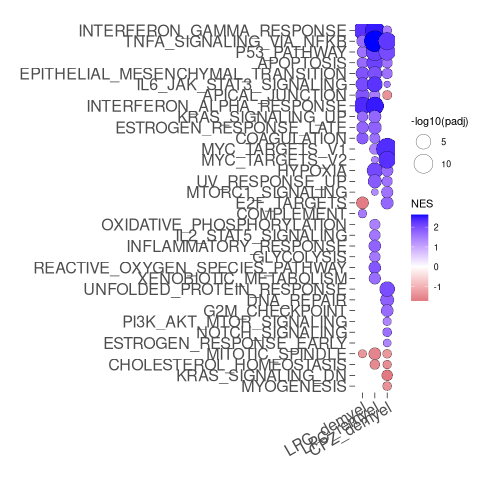

In [160]:
%%R

heatmap_plot <- ggplot(filtered_df, aes(y = pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") +
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(3, 10)) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_text(size = 16, vjust = 0.5),
    axis.text.x = element_text(angle = 30, hjust = 1, size = 16, vjust = 1),
    axis.ticks = element_line(linewidth = 0.3),
    axis.ticks.length = unit(0.2, "cm")
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

print(heatmap_plot)

#ggsave("./figures/GSEA/heatmap_pathway_NES_padj_MOL_ordered_resized.png", plot = heatmap_plot, dpi = 300, width = 8, height = 8)

In [161]:
%%R

# Dictionary to format pathway names
pathway_name_format <- list(
  "INTERFERON_GAMMA_RESPONSE"      = "Interferon-γ Response",
  "TNFA_SIGNALING_VIA_NFKB"        = "TNFα Signaling via NF-κB",
  "P53_PATHWAY"                    = "p53 Pathway",
  "APOPTOSIS"                      = "Apoptosis",
  "EPITHELIAL_MESENCHYMAL_TRANSITION" = "Epithelial-Mesenchymal Transition",
  "IL6_JAK_STAT3_SIGNALING"        = "IL-6/JAK/STAT3 Signaling",
  "APICAL_JUNCTION"                = "Apical Junction",
  "INTERFERON_ALPHA_RESPONSE"      = "Interferon-α Response",
  "KRAS_SIGNALING_UP"              = "KRAS Signaling (Up)",
  "ESTROGEN_RESPONSE_LATE"         = "Estrogen Response (Late)",
  "COAGULATION"                    = "Coagulation",
  "MYC_TARGETS_V1"                 = "MYC Targets V1",
  "MYC_TARGETS_V2"                 = "MYC Targets V2",
  "HYPOXIA"                        = "Hypoxia",
  "UV_RESPONSE_UP"                 = "UV Response (Up)",
  "MTORC1_SIGNALING"               = "mTORC1 Signaling",
  "E2F_TARGETS"                    = "E2F Targets",
  "COMPLEMENT"                     = "Complement",
  "OXIDATIVE_PHOSPHORYLATION"      = "Oxidative Phosphorylation",
  "IL2_STAT5_SIGNALING"            = "IL-2/STAT5 Signaling",
  "INFLAMMATORY_RESPONSE"          = "Inflammatory Response",
  "GLYCOLYSIS"                     = "Glycolysis",
  "REACTIVE_OXYGEN_SPECIES_PATHWAY"= "Reactive Oxygen Species Pathway",
  "XENOBIOTIC_METABOLISM"          = "Xenobiotic Metabolism",
  "UNFOLDED_PROTEIN_RESPONSE"      = "Unfolded Protein Response",
  "PI3K_AKT_MTOR_SIGNALING"        = "PI3K/AKT/mTOR Signaling",
  "NOTCH_SIGNALING"                = "Notch Signaling",
  "ESTROGEN_RESPONSE_EARLY"        = "Estrogen Response (Early)",
  "DNA_REPAIR"                     = "DNA Repair",
  "G2M_CHECKPOINT"                 = "G2/M Checkpoint",
  "MITOTIC_SPINDLE"                = "Mitotic Spindle",
  "CHOLESTEROL_HOMEOSTASIS"        = "Cholesterol Homeostasis",
  "KRAS_SIGNALING_DN"              = "KRAS Signaling (Down)",
  "MYOGENESIS"                     = "Myogenesis"
)

# Reverse the desired pathway order
reversed_pathway_order <- rev(desired_pathway_order)

# Add formatted pathway names to the dataframe
filtered_df$formatted_pathway <- pathway_name_format[as.character(filtered_df$pathway)]

# Reorder the 'formatted_pathway' column based on reversed pathway order
filtered_df$formatted_pathway <- factor(filtered_df$formatted_pathway, levels = pathway_name_format[reversed_pathway_order])

# Verify the new order
print(levels(filtered_df$formatted_pathway))

 [1] "Myogenesis"                        "KRAS Signaling (Down)"            
 [3] "Cholesterol Homeostasis"           "Mitotic Spindle"                  
 [5] "Estrogen Response (Early)"         "Notch Signaling"                  
 [7] "PI3K/AKT/mTOR Signaling"           "G2/M Checkpoint"                  
 [9] "DNA Repair"                        "Unfolded Protein Response"        
[11] "Xenobiotic Metabolism"             "Reactive Oxygen Species Pathway"  
[13] "Glycolysis"                        "Inflammatory Response"            
[15] "IL-2/STAT5 Signaling"              "Oxidative Phosphorylation"        
[17] "Complement"                        "E2F Targets"                      
[19] "mTORC1 Signaling"                  "UV Response (Up)"                 
[21] "Hypoxia"                           "MYC Targets V2"                   
[23] "MYC Targets V1"                    "Coagulation"                      
[25] "Estrogen Response (Late)"          "KRAS Signaling (Up)"              

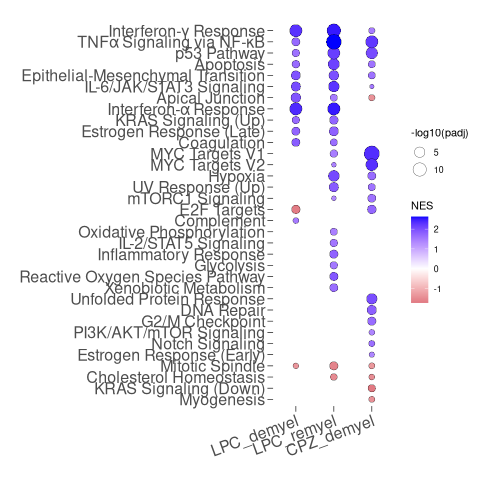

In [210]:
%%R

# Create the heatmap plot
heatmap_plot <- ggplot(filtered_df, aes(y = formatted_pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") +
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(2, 7)) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_text(size = 16, vjust = 0.5),
    axis.text.x = element_text(angle = 20, hjust = 1, size = 16, vjust = 1),
    axis.ticks = element_line(linewidth = 0.3),
    axis.ticks.length = unit(0.2, "cm")
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

# Print the heatmap
print(heatmap_plot)

# Save the heatmap plot
ggsave("./figures/GSEA/heatmap_pathway_NES_padj_MOL_ordered_allgenes.png",
       plot = heatmap_plot,
       dpi = 300,
       width = 8.5,
       height = 10)  # increased height from 8 → 10

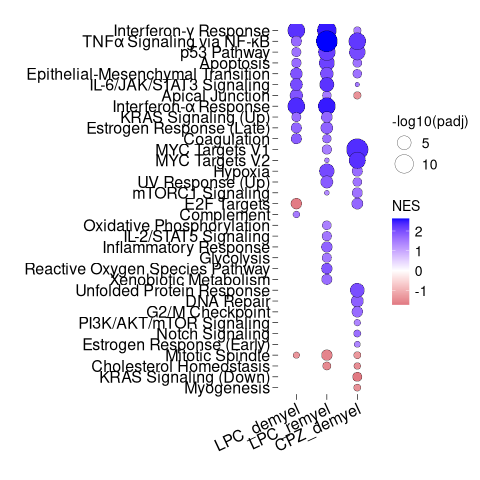

In [211]:
%%R

# Create the heatmap plot
heatmap_plot <- ggplot(filtered_df, aes(y = formatted_pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") +
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(2, 10)) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_text(size = 16, vjust = 0.5, colour = "black"),
    axis.text.x = element_text(angle = 25, hjust = 1, size = 16, vjust = 1, colour = "black"),
    axis.title.x = element_text(size = 16, colour = "black"),
    axis.title.y = element_text(size = 16, colour = "black"),
    axis.ticks = element_line(linewidth = 0.3),
    axis.ticks.length = unit(0.2, "cm"),
    legend.text = element_text(colour = "black", size = 14),
    legend.title = element_text(colour = "black", size = 14)
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

# Print the heatmap
print(heatmap_plot)

# Save the heatmap plot
ggsave(
  "./figures/GSEA/heatmap_pathway_NES_padj_MOL_ordered_allgenes.png",
  plot = heatmap_plot,
  dpi = 300,
  width = 7.5,
  height = 8
)

# OPC

In [169]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/LPC_OPC_early_voom_wqw_UPDATED.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

       gene     logFC  AveExpr         t      P.Value    adj.P.Val        B
1       C4b  4.969368 5.166741  17.92496 1.262250e-11 1.019015e-07 15.94549
2 Serpina3n  5.016019 5.574485  16.22826 5.319566e-11 1.760439e-07 15.14196
3    Dbndd2  4.443583 4.783055  15.99661 6.541952e-11 1.760439e-07 14.73933
4   Col16a1  2.322603 5.886618  15.56691 9.670652e-11 1.951779e-07 14.77328
5    Unc13c -2.726557 6.612704 -13.55744 6.896989e-10 9.751585e-07 12.69665
6     Josd2  3.069189 4.524543  13.50979 7.247555e-10 9.751585e-07 12.74182


In [170]:
%%R

dim(df)

[1] 8073    7


In [171]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "C4b"       "Serpina3n" "Dbndd2"    "Col16a1"   "Unc13c"    "Josd2"    


In [172]:
%%R
# Check column names in the dataframe
colnames(df)

[1] "gene"      "logFC"     "AveExpr"   "t"         "P.Value"   "adj.P.Val"
[7] "B"        


In [173]:
%%R

# Compute ranking score: sign(logFC) * -log10(P.Value)
df$ranking_score <- sign(df$logFC) * -log10(df$P.Value)

# Assign names to the rankings
rankings <- df$ranking_score
names(rankings) <- df$gene

# Sort the rankings in descending order
rankings <- sort(rankings, decreasing = TRUE)

In [174]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


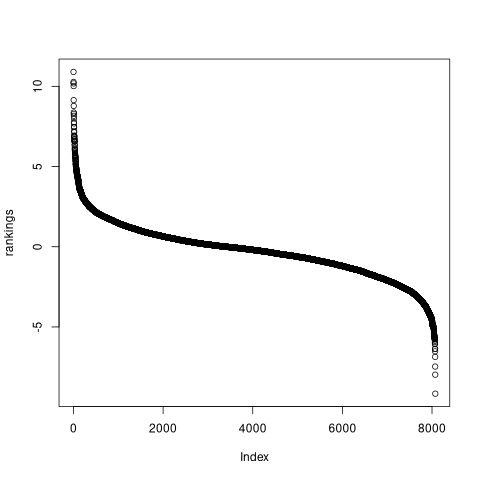

In [175]:
%%R

plot(rankings)

In [176]:
%%R

max(rankings)

[1] 10.89885


In [177]:
%%R

min(rankings)

[1] -9.16134


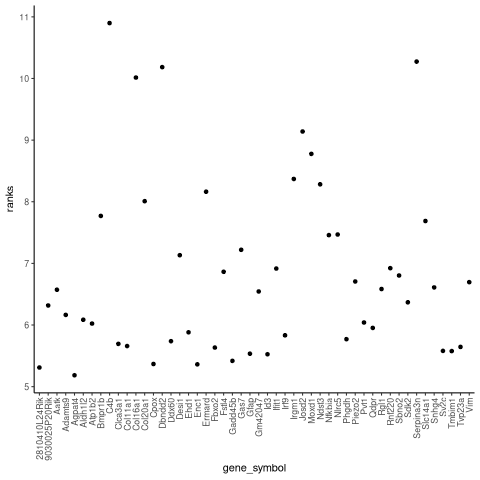

In [178]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Set up gene lists

In [179]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [180]:
%%R
fgsea_res

                                       pathway         pval         padj
                                        <char>        <num>        <num>
 1:                      HALLMARK_ADIPOGENESIS 1.398886e-02 2.988530e-02
 2:               HALLMARK_ALLOGRAFT_REJECTION 3.411180e-03 1.233273e-02
 3:                 HALLMARK_ANDROGEN_RESPONSE 6.444444e-01 7.970760e-01
 4:                   HALLMARK_APICAL_JUNCTION 4.459279e-01 5.988175e-01
 5:                         HALLMARK_APOPTOSIS 4.722236e-03 1.387157e-02
 6:              HALLMARK_BILE_ACID_METABOLISM 5.570142e-05 3.739952e-04
 7:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 4.404070e-02 8.279652e-02
 8:                       HALLMARK_COAGULATION 3.589744e-01 4.962293e-01
 9:                        HALLMARK_COMPLEMENT 8.389716e-01 8.961742e-01
10:                        HALLMARK_DNA_REPAIR 1.540088e-04 7.898813e-04
11:                       HALLMARK_E2F_TARGETS 3.541693e-06 2.774326e-05
12: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 2.07

In [181]:
%%R

dim(fgsea_res)

[1] 47  8


In [182]:
%%R

fwrite(fgsea_res, file = "./files/fgsea_Cupr_demyel_MOL_allgenes.csv")

In [183]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL4_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL4_significant)

[1] 25  8


In [184]:
%%R

head(fgsea_MOL4_significant)

                            pathway         pval         padj   log2err
                             <char>        <num>        <num>     <num>
1:            HALLMARK_ADIPOGENESIS 1.398886e-02 0.0298852973 0.3807304
2:     HALLMARK_ALLOGRAFT_REJECTION 3.411180e-03 0.0123327270 0.4317077
3:               HALLMARK_APOPTOSIS 4.722236e-03 0.0138715695 0.4070179
4:    HALLMARK_BILE_ACID_METABOLISM 5.570142e-05 0.0003739952 0.5573322
5: HALLMARK_CHOLESTEROL_HOMEOSTASIS 4.404070e-02 0.0827965165 0.3217759
6:              HALLMARK_DNA_REPAIR 1.540088e-04 0.0007898813 0.5188481
           ES       NES  size                               leadingEdge
        <num>     <num> <int>                                    <list>
1:  0.3097458  1.400456   132   Qdpr,Taldo1,Samm50,Pim3,Ak2,Dnajc15,...
2:  0.4294806  1.682711    57     Tgfb2,Apbb1,Nme1,Csf1,Stat1,Eif5a,...
3:  0.3721996  1.512298    73  Gadd45b,Tgfb2,Cdkn1a,Casp3,Lmna,Ier3,...
4: -0.6168784 -1.982719    41 Abca6,Nr3c2,Hsd17b11,Optn,Idi1,Cyp

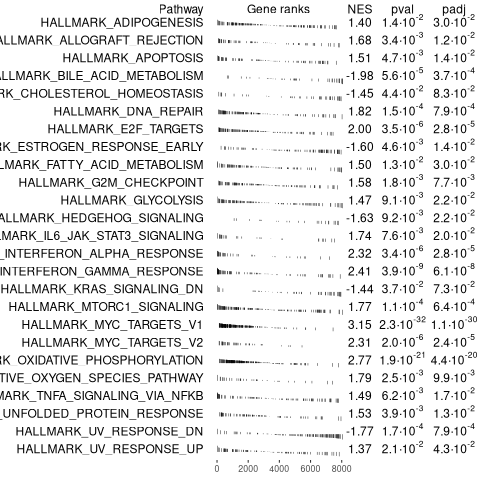

In [185]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL4_significant$pathway], 
              rankings, 
              fgsea_MOL4_significant, 
              gseaParam = 0.5)

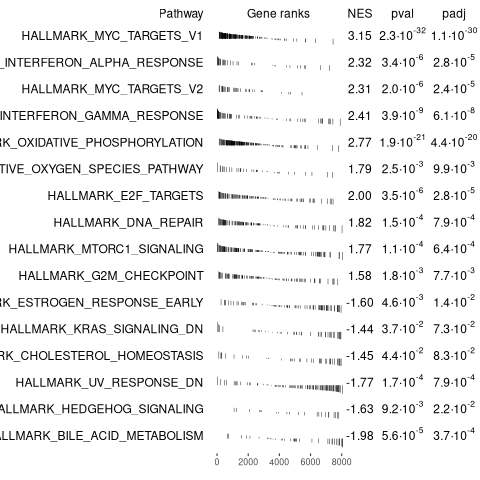

In [186]:
%%R

topUp <- fgsea_MOL4_significant %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)

topDown <- fgsea_MOL4_significant %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)

topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)

plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_MOL4_significant, 
              gseaParam = 0.5)

In [187]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL4_significant[order(pval)][padj < 0.05], 
                                      pathwaysH, rankings)

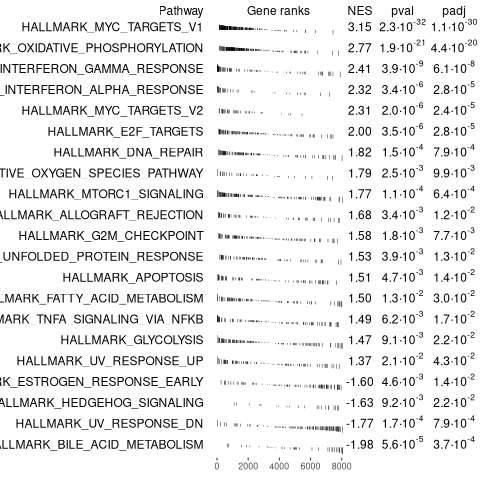

In [188]:
%%R

mainPathways <- fgsea_MOL4_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL4_significant, 
              gseaParam = 0.5)

In [189]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

In [190]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                padj   NES  size
  <chr>                                 <dbl> <dbl> <int>
1 HALLMARK_MYC_TARGETS_V1            1.09e-30  3.15   180
2 HALLMARK_OXIDATIVE_PHOSPHORYLATION 4.42e-20  2.77   181
3 HALLMARK_INTERFERON_GAMMA_RESPONSE 6.15e- 8  2.41    69
4 HALLMARK_MYC_TARGETS_V2            2.35e- 5  2.31    35
5 HALLMARK_INTERFERON_ALPHA_RESPONSE 2.77e- 5  2.32    32
6 HALLMARK_E2F_TARGETS               2.77e- 5  2.00   106


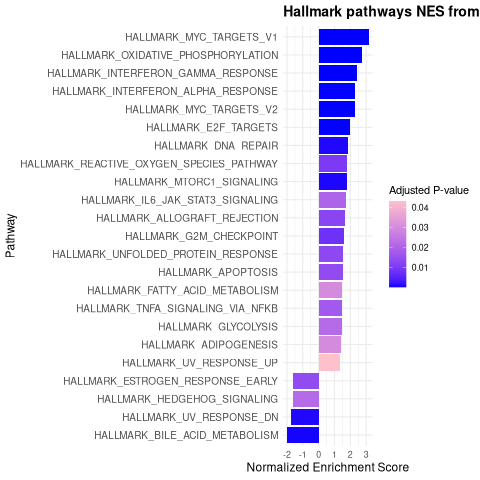

In [191]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "blue", high = "pink", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

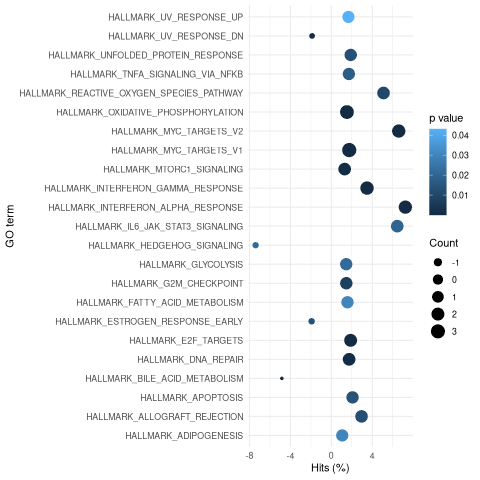

In [192]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [193]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                padj   NES  size
  <chr>                                 <dbl> <dbl> <int>
1 HALLMARK_MYC_TARGETS_V1            1.09e-30  3.15   180
2 HALLMARK_OXIDATIVE_PHOSPHORYLATION 4.42e-20  2.77   181
3 HALLMARK_INTERFERON_GAMMA_RESPONSE 6.15e- 8  2.41    69
4 HALLMARK_MYC_TARGETS_V2            2.35e- 5  2.31    35
5 HALLMARK_INTERFERON_ALPHA_RESPONSE 2.77e- 5  2.32    32
6 HALLMARK_E2F_TARGETS               2.77e- 5  2.00   106


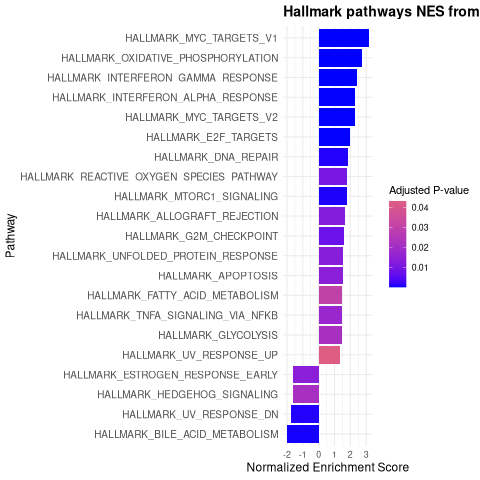

In [194]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )


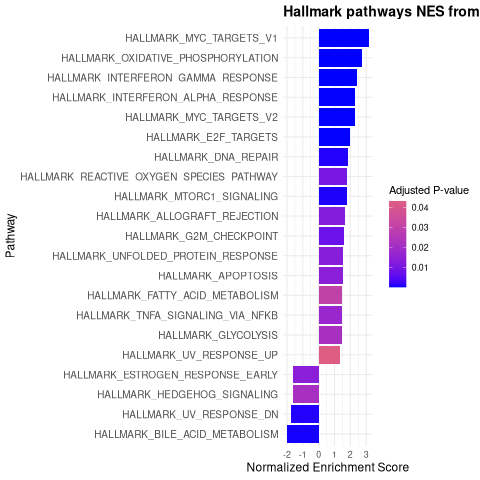

In [195]:
%%R

# Create the ggplot
plot <- # Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/Cupr_demyel_MOL_G_reduced_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [196]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                       padj   NES  size
  <chr>                        <dbl> <dbl> <int>
1 MYC_TARGETS_V1            1.09e-30  3.15   180
2 OXIDATIVE_PHOSPHORYLATION 4.42e-20  2.77   181
3 INTERFERON_GAMMA_RESPONSE 6.15e- 8  2.41    69
4 MYC_TARGETS_V2            2.35e- 5  2.31    35
5 INTERFERON_ALPHA_RESPONSE 2.77e- 5  2.32    32
6 E2F_TARGETS               2.77e- 5  2.00   106


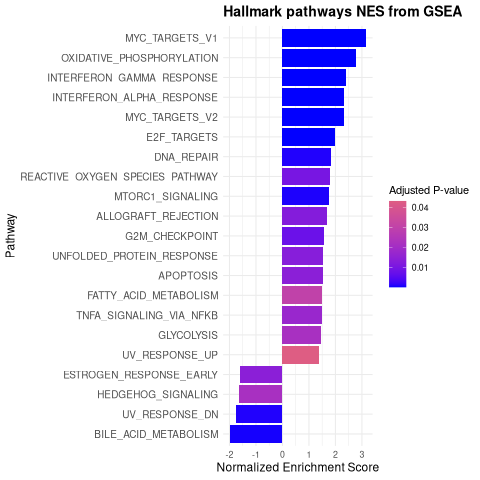

In [197]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/LPC_remyel_MOL_hallmark_pathways_NES_GSEA_trimmed.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

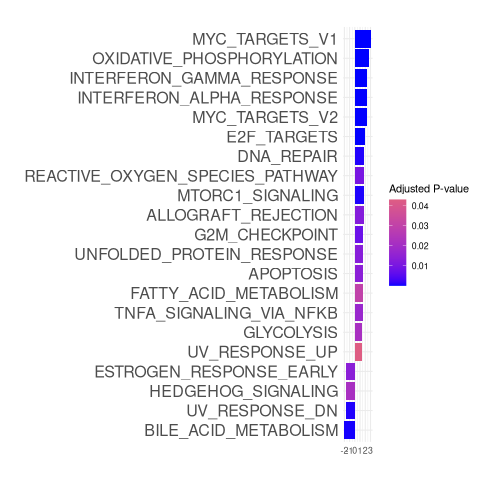

In [198]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 16),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 16, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/Cupr_demyel_MOL_reduced_hallmark_pathways_NES_GSEA_trimmed.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [206]:
%%R

filtered_fgseaResSignificant_LPC_remyel <- fgsea_MOL4_significant
# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant_LPC_remyel$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant_LPC_remyel$pathway)
head(filtered_fgseaResSignificant_LPC_remyel)

                   pathway         pval         padj   log2err         ES
                    <char>        <num>        <num>     <num>      <num>
1:            ADIPOGENESIS 1.398886e-02 0.0298852973 0.3807304  0.3097458
2:     ALLOGRAFT_REJECTION 3.411180e-03 0.0123327270 0.4317077  0.4294806
3:               APOPTOSIS 4.722236e-03 0.0138715695 0.4070179  0.3721996
4:    BILE_ACID_METABOLISM 5.570142e-05 0.0003739952 0.5573322 -0.6168784
5: CHOLESTEROL_HOMEOSTASIS 4.404070e-02 0.0827965165 0.3217759 -0.4555574
6:              DNA_REPAIR 1.540088e-04 0.0007898813 0.5188481  0.4189501
         NES  size                               leadingEdge
       <num> <int>                                    <list>
1:  1.400456   132   Qdpr,Taldo1,Samm50,Pim3,Ak2,Dnajc15,...
2:  1.682711    57     Tgfb2,Apbb1,Nme1,Csf1,Stat1,Eif5a,...
3:  1.512298    73  Gadd45b,Tgfb2,Cdkn1a,Casp3,Lmna,Ier3,...
4: -1.982719    41 Abca6,Nr3c2,Hsd17b11,Optn,Idi1,Cyp7b1,...
5: -1.454420    40  Pcyt2,Nsdhl,Idi1,Hmgcr

In [207]:
%%R
unique(filtered_fgseaResSignificant_LPC_remyel$pathway)

 [1] "ADIPOGENESIS"                    "ALLOGRAFT_REJECTION"            
 [3] "APOPTOSIS"                       "BILE_ACID_METABOLISM"           
 [5] "CHOLESTEROL_HOMEOSTASIS"         "DNA_REPAIR"                     
 [7] "E2F_TARGETS"                     "ESTROGEN_RESPONSE_EARLY"        
 [9] "FATTY_ACID_METABOLISM"           "G2M_CHECKPOINT"                 
[11] "GLYCOLYSIS"                      "HEDGEHOG_SIGNALING"             
[13] "IL6_JAK_STAT3_SIGNALING"         "INTERFERON_ALPHA_RESPONSE"      
[15] "INTERFERON_GAMMA_RESPONSE"       "KRAS_SIGNALING_DN"              
[17] "MTORC1_SIGNALING"                "MYC_TARGETS_V1"                 
[19] "MYC_TARGETS_V2"                  "OXIDATIVE_PHOSPHORYLATION"      
[21] "REACTIVE_OXYGEN_SPECIES_PATHWAY" "TNFA_SIGNALING_VIA_NFKB"        
[23] "UNFOLDED_PROTEIN_RESPONSE"       "UV_RESPONSE_DN"                 
[25] "UV_RESPONSE_UP"                 


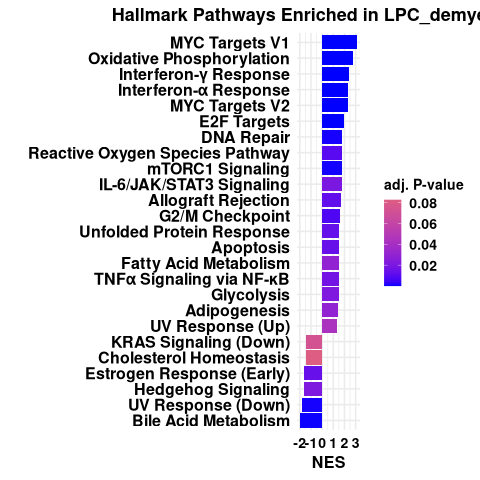

In [209]:
%%R
# Define your selected pathways and their pretty names
# Define your selected pathways and their pretty names
pathway_name_format <- c(
  "ADIPOGENESIS"                    = "Adipogenesis",
  "ALLOGRAFT_REJECTION"             = "Allograft Rejection",
  "APOPTOSIS"                       = "Apoptosis",
  "BILE_ACID_METABOLISM"            = "Bile Acid Metabolism",
  "CHOLESTEROL_HOMEOSTASIS"         = "Cholesterol Homeostasis",
  "DNA_REPAIR"                      = "DNA Repair",
  "E2F_TARGETS"                     = "E2F Targets",
  "ESTROGEN_RESPONSE_EARLY"         = "Estrogen Response (Early)",
  "FATTY_ACID_METABOLISM"           = "Fatty Acid Metabolism",
  "G2M_CHECKPOINT"                  = "G2/M Checkpoint",
  "GLYCOLYSIS"                      = "Glycolysis",
  "HEDGEHOG_SIGNALING"              = "Hedgehog Signaling",
  "IL6_JAK_STAT3_SIGNALING"         = "IL-6/JAK/STAT3 Signaling",
  "INTERFERON_ALPHA_RESPONSE"       = "Interferon-α Response",
  "INTERFERON_GAMMA_RESPONSE"       = "Interferon-γ Response",
  "KRAS_SIGNALING_DN"               = "KRAS Signaling (Down)",
  "MTORC1_SIGNALING"                = "mTORC1 Signaling",
  "MYC_TARGETS_V1"                  = "MYC Targets V1",
  "MYC_TARGETS_V2"                  = "MYC Targets V2",
  "OXIDATIVE_PHOSPHORYLATION"       = "Oxidative Phosphorylation",
  "REACTIVE_OXYGEN_SPECIES_PATHWAY" = "Reactive Oxygen Species Pathway",
  "TNFA_SIGNALING_VIA_NFKB"         = "TNFα Signaling via NF-κB",
  "UNFOLDED_PROTEIN_RESPONSE"       = "Unfolded Protein Response",
  "UV_RESPONSE_DN"                  = "UV Response (Down)",
  "UV_RESPONSE_UP"                  = "UV Response (Up)"
)


# Filter only the selected pathways and apply pretty names
filtered_fgseaResSignificant_LPC_remyel <- filtered_fgseaResSignificant_LPC_remyel %>%
  filter(pathway %in% names(pathway_name_format)) %>%
  mutate(pretty_pathway = pathway_name_format[pathway])

# Create the improved ggplot
plot <- ggplot(filtered_fgseaResSignificant_LPC_remyel, aes(reorder(pretty_pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(
    low = "#0000FF",
    high = "#de5d83",
    na.value = "black",
    name = "adj. P-value"
  ) +
  labs(
    x = "",
    y = "NES",
    title = "Hallmark Pathways Enriched in LPC_demyel OPCs"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    axis.text.y = element_text(size = 16, face = "bold", color = "black"),
    axis.text.x = element_text(size = 14, face = "bold", color = "black"),
    axis.title = element_text(size = 16, face = "bold", color = "black"),
    plot.title = element_text(size = 18, face = "bold", color = "black", hjust = 0.5),
    legend.title = element_text(size = 14, face = "bold", color = "black"),
    legend.text = element_text(size = 14, face = "bold", color = "black")
  )

# Save high-resolution PNG
ggsave("./figures/GSEA/OPC_LPCde_selected_hallmark_pathways_NES_GSEA.png",
       plot = plot, dpi = 300, width = 10, height = 8)

print(plot)